In [1]:
'''
Author: LiuSheng
Date: 2025-03-20 10:29:26
LastEditTime: 2025-03-20 10:36:25
Description: 
'''
import os
import numpy as np
from glob import glob
import SimpleITK as sitk
import matplotlib.pyplot as plt

from cardiac.segment.seg319.utils import read_sitk_img
# from cardiac.segment.seg319.seg319 import lv_segment

from cardiac.bulleye_gen import gen_bulleye

In [2]:
'''
Author: LiuSheng
Date: 2025-03-20 09:41:37
LastEditTime: 2025-03-21 09:53:26
Description: 
'''
import numpy as np
import copy
import json

from cardiac.segment.seg319.sub_func import init_img3d
from cardiac.segment.seg319.sub_func import naive_segment_lv_mask
from cardiac.segment.seg319.sub_func import naive_cal_circle_param
from cardiac.segment.seg319.sub_func import determine_apex_base
from cardiac.segment.seg319.sub_func import cal_sector_masks
from cardiac.segment.seg319.sub_func import select_points
from cardiac.segment.seg319.sub_func import create_triangles
from cardiac.segment.seg319.sub_func import mesh_voxelize

from cardiac.segment.seg319.visualize import plot_for_naive_cal_circle_param
from cardiac.segment.seg319.visualize import show_3d_mask
from cardiac.segment.seg319.visualize import show_mesh

def lv_segment(img3d, voxel_size, verbose=0, save_dir=None):
    img3d = img3d+0
    img3d[img3d<0] = 0
    
    print("************************************************************************************************")
    print(f"input img3d: {img3d.shape}, voxel_size: {voxel_size}")
    print("************************************************************************************************")
    
    # 初始化
    img3d = init_img3d(img3d)
    # 粗分割 mask
    naive_lv_mask = naive_segment_lv_mask(img3d, voxel_size)
    # 定位 center radius
    circle_param, others = naive_cal_circle_param(img3d, naive_lv_mask)
    # 定位 apex_z, base_z
    loc_info = determine_apex_base(img3d, circle_param)
    naive_param = copy.deepcopy(circle_param)
    naive_param.update(loc_info)
    
    print(f"naive_param: {json.dumps(naive_param, indent=4)}")
    
    if verbose:
        plot_for_naive_cal_circle_param(others["summed_img2d"], others["intensity_mask"], naive_param, others["mask_inner"])
    
    
    ### 这里可以添加微调位置: naive_param
    sector_masks, points_theoretical = cal_sector_masks(img3d, naive_param, verbose=0)
    
    points = select_points(img3d, sector_masks, points_theoretical)
    triangles = create_triangles(points)
    if verbose:
        show_mesh(points, triangles, save_dir)
    
    mask_array = mesh_voxelize(img3d, points, triangles)
    
    if verbose:
        show_3d_mask(mask_array, save_dir)
    
    return mask_array, naive_param



In [3]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import normalized_root_mse as nrmse

def cal_metric(std_polar_map, input_polar_map):

    # 计算 PSNR
    psnr_value = psnr(std_polar_map, input_polar_map, data_range=std_polar_map.max() - std_polar_map.min())

    ssim_value = ssim(std_polar_map, input_polar_map, data_range=std_polar_map.max() - std_polar_map.min())
    # 计算 NRMSE
    nrmse_value = nrmse(std_polar_map, input_polar_map)


    print(f"PSNR: {psnr_value}, SSIM: {ssim_value}, NRMSE: {nrmse_value}")
    
    return psnr_value, ssim_value, nrmse_value

In [10]:
def show_bulleye(std_bulleye, gen_bulleye, save_dir=None):
    fig = plt.figure(figsize=(10, 3))

    # 第一个子图
    ax1 = plt.subplot(131)
    im1 = ax1.imshow(std_bulleye)
    ax1.set_title("std_bulleye")
    ax1.axis("off")
    plt.colorbar(im1, ax=ax1)

    # 第二个子图
    ax2 = plt.subplot(132)
    im2 = ax2.imshow(gen_bulleye)
    ax2.set_title("gen_bulleye")
    ax2.axis("off")
    plt.colorbar(im2, ax=ax2)

    # 第三个子图
    ax3 = plt.subplot(133)
    im3 = ax3.imshow(std_bulleye - gen_bulleye)
    ax3.set_title("diff: std - gen")
    ax3.axis("off")
    plt.colorbar(im3, ax=ax3)

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, "bulleye.png"))
    plt.show()


patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0000
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (57, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:68149.62255761097, distance:7.606751305475518
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 32.85025145234786,
        "cx": 29.049716049355293
    },
    "radius": 11.415992323701115,
    "apex_z": 9,
    "base_z": 45,
    "dividing_z": 29.12398848555167
}


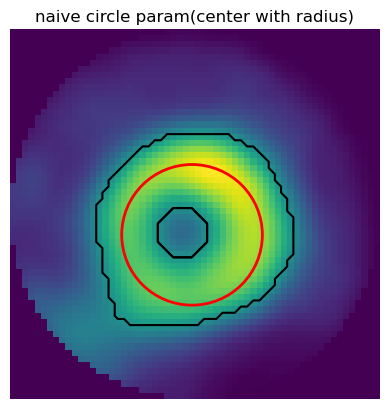

points_theoretical: (922, 3)
before: 640
after: 920
final: 921


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


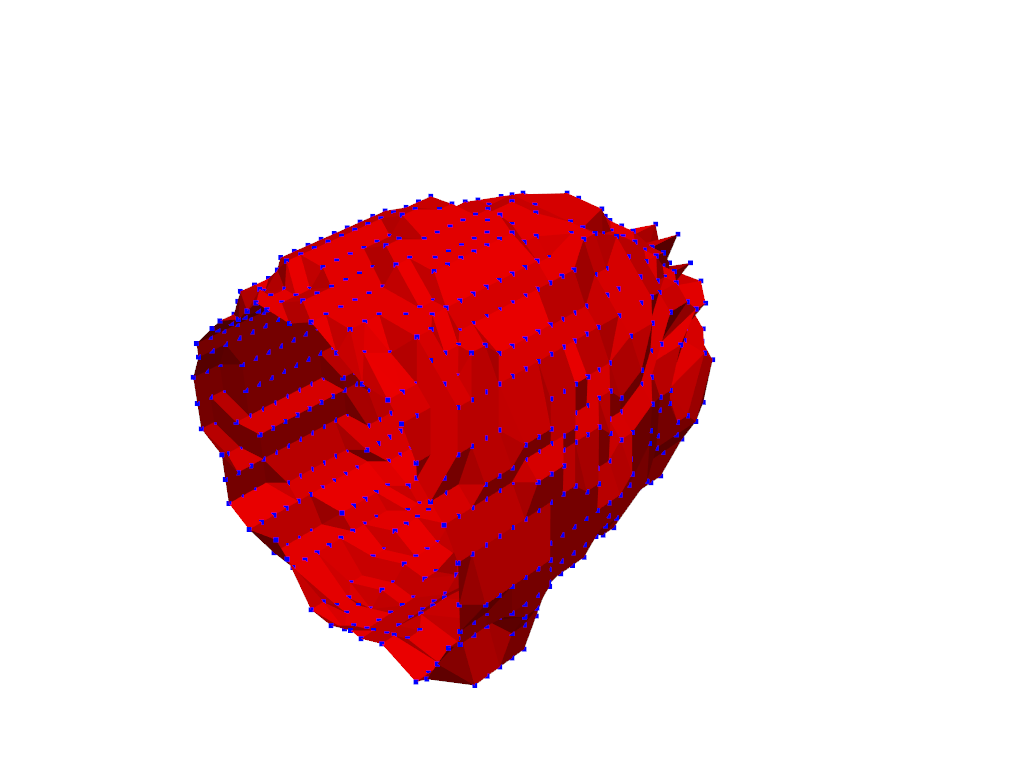

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


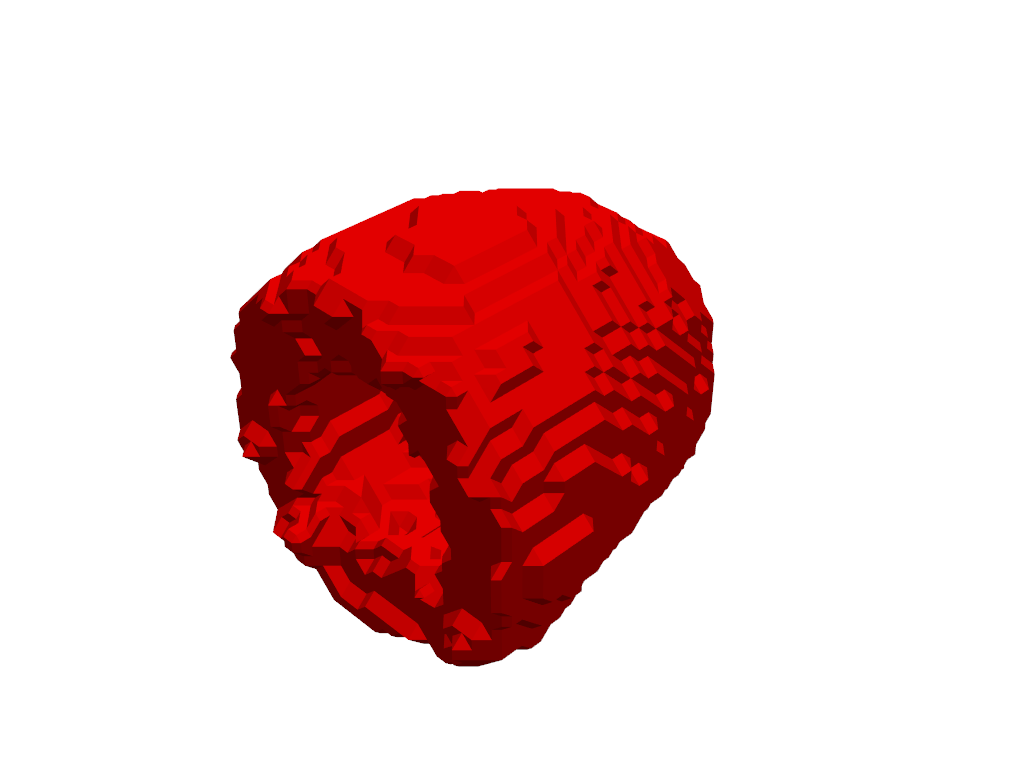

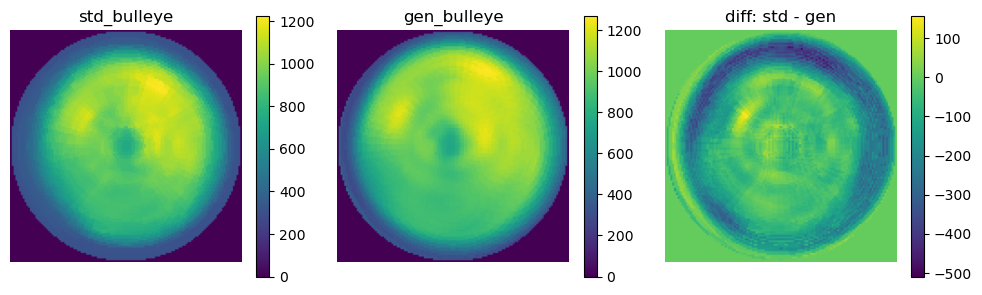

PSNR: 19.172708974983756, SSIM: 0.7785280619279419, NRMSE: 0.19547818078138215
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0001
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (57, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:44065.00050328333, distance:27.404556076104985
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 31.613608365069936,
        "cx": 30.26664295969377
    },
    "radius": 14.911089266477378,
    "apex_z": 3,
    "base_z": 43,
    "dividing_z": 28.366633899716067
}


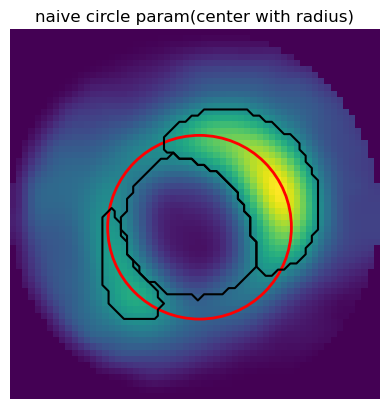

points_theoretical: (882, 3)
before: 600
after: 880
final: 881


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


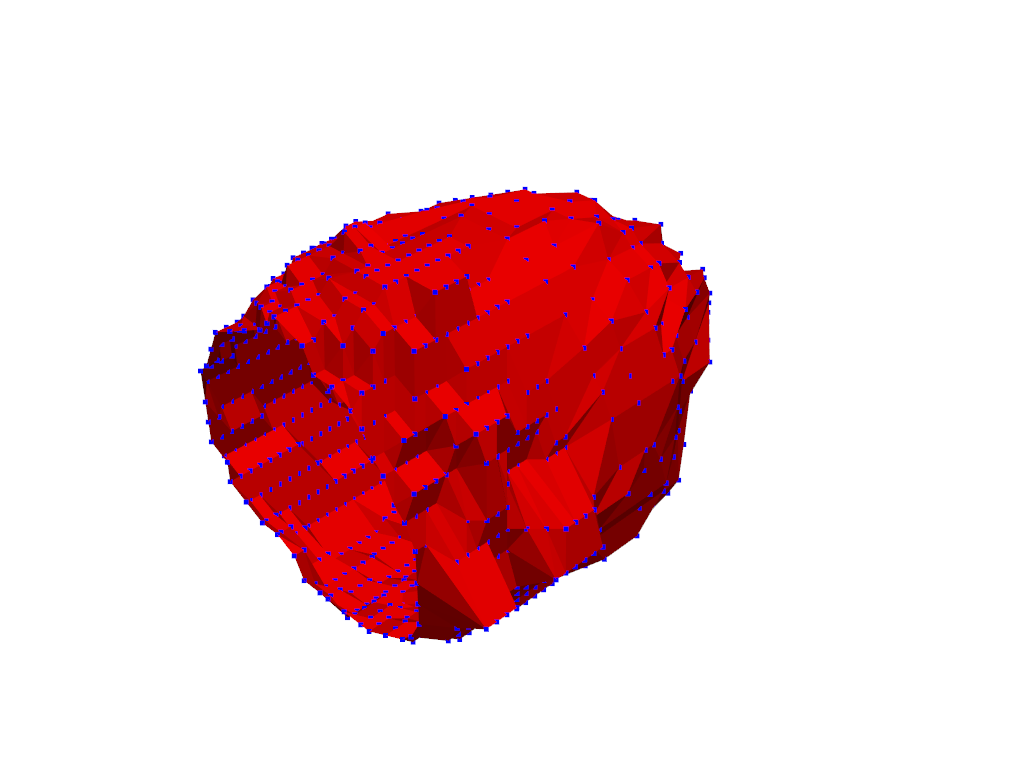

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


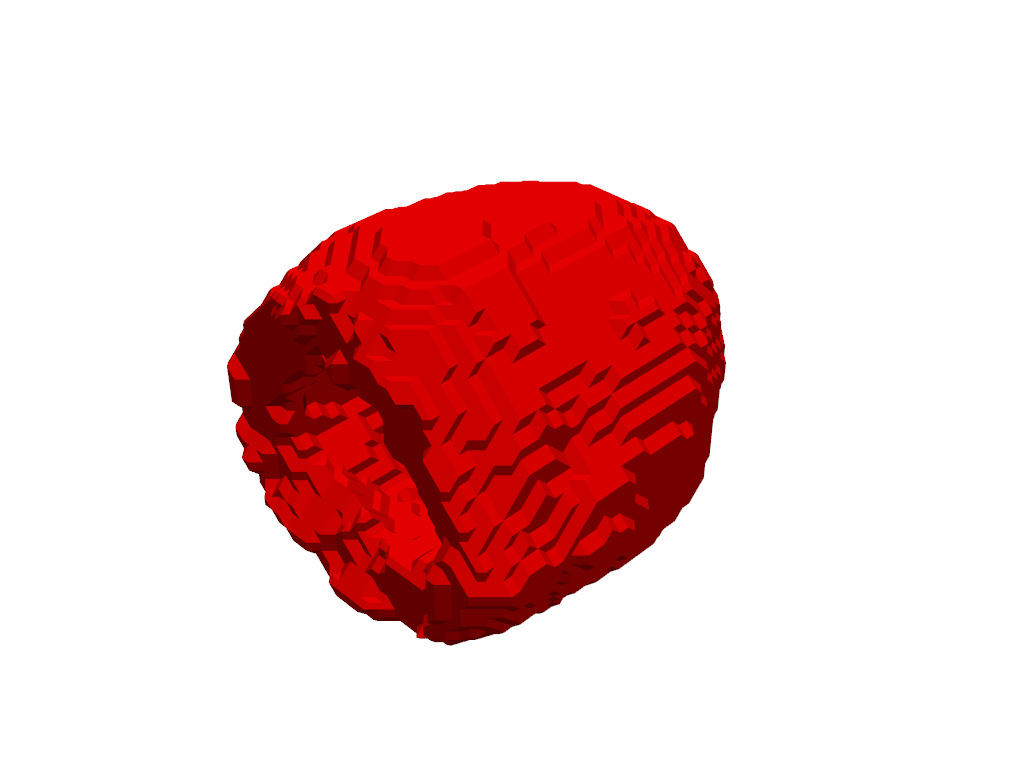

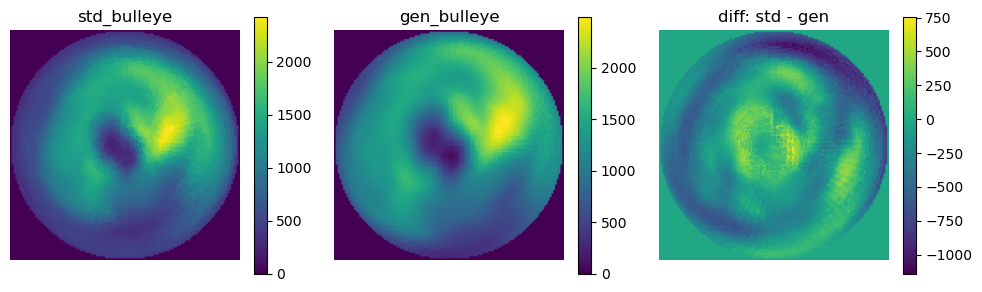

PSNR: 17.253319075801926, SSIM: 0.626030933653352, NRMSE: 0.34189896361351263
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0002
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (51, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:69442.26750621878, distance:23.98620561022382
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 26.356877676710297,
        "cx": 28.38780614575249
    },
    "radius": 10.59782174984022,
    "apex_z": 0,
    "base_z": 41,
    "dividing_z": 18.89673262476033
}


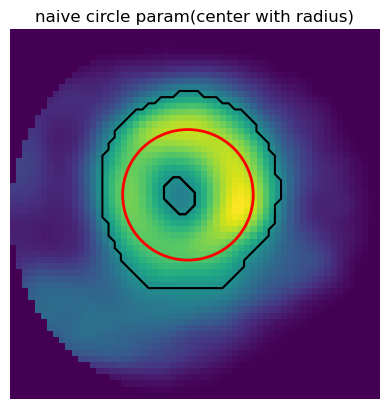

points_theoretical: (1202, 3)
before: 920
after: 1200
final: 1201


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


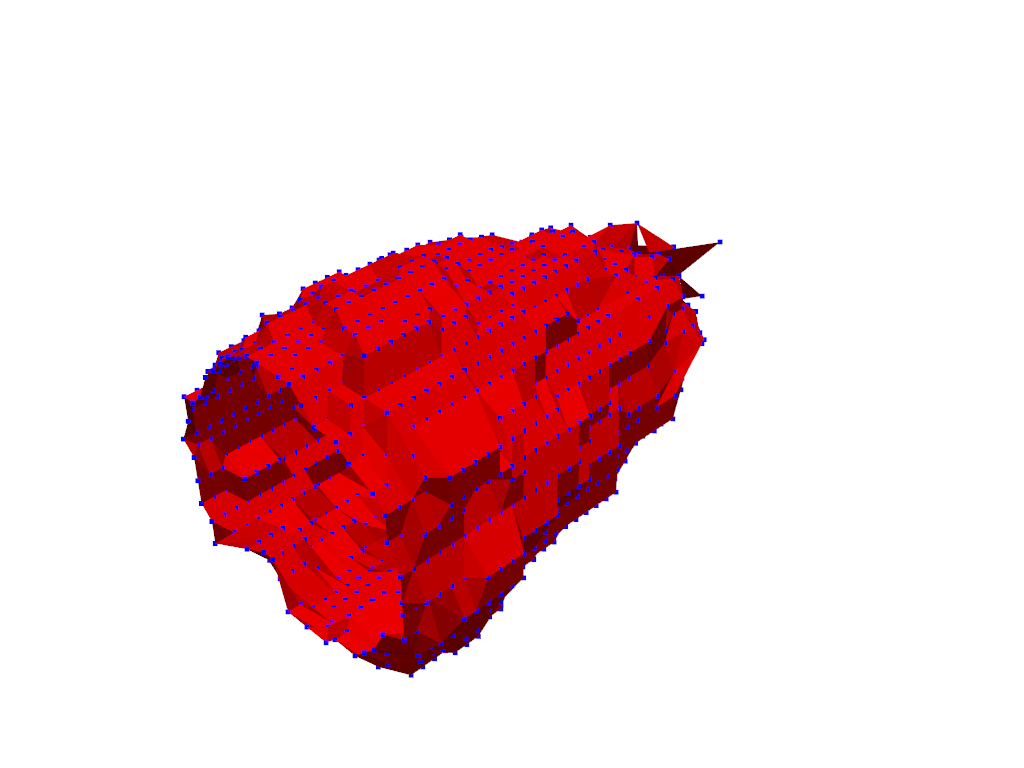

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


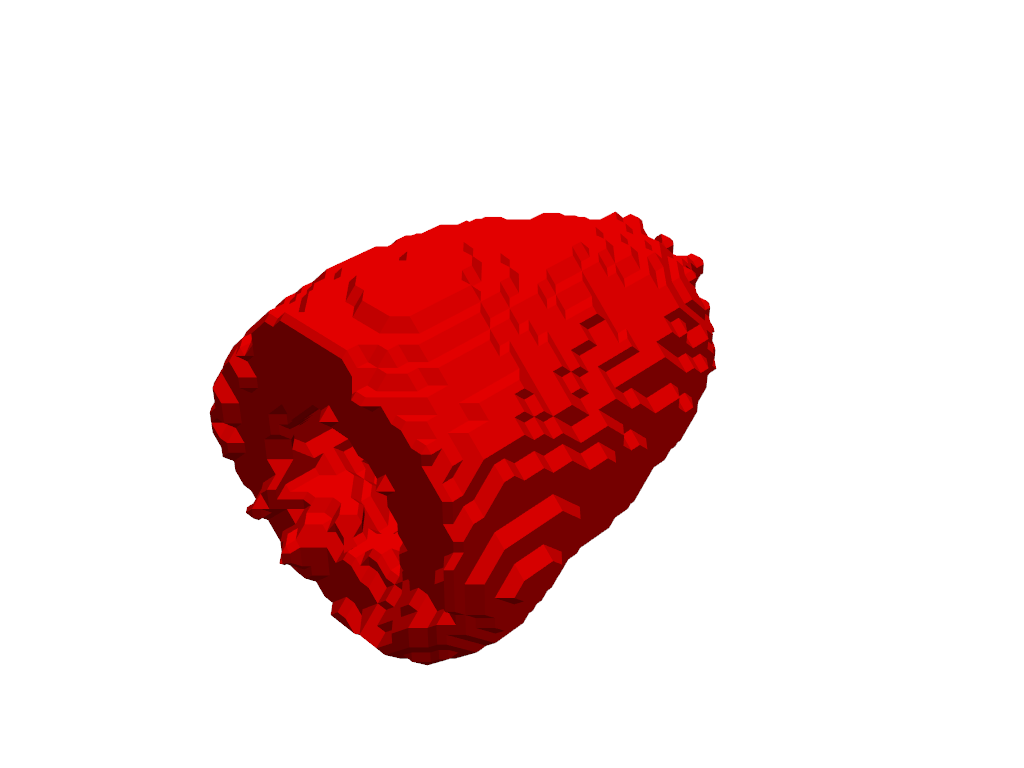

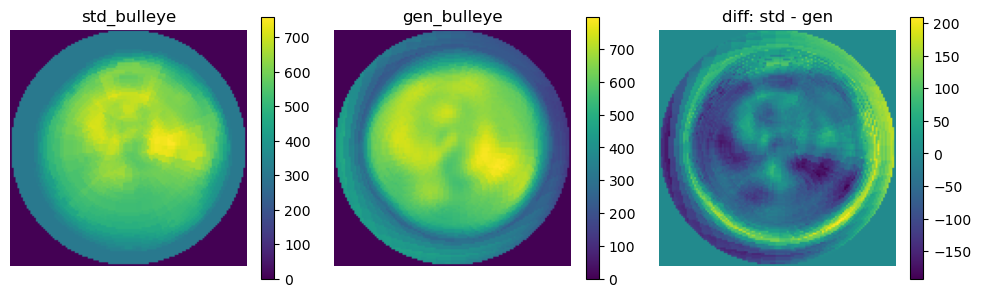

PSNR: 20.48120376422617, SSIM: 0.6493796176589817, NRMSE: 0.16381988333243008
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0003
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (57, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:98927.61385621347, distance:32.534217552303446
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:237.8159846103383, distance:110.92959022140258
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:30.685933498108167, distance:113.80264849736456
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 26.0,
        "cx": 28.211221972272064
    },
    "radius": 15.120966134421415,
    "apex_z": 0,
    "base_z": 40,
    "divi

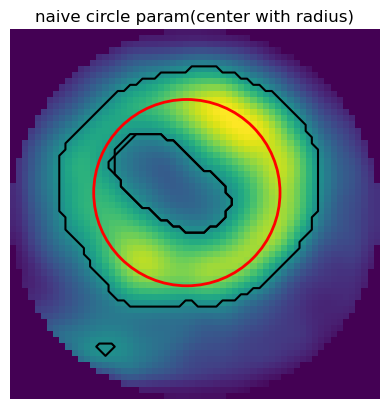

points_theoretical: (882, 3)
before: 600
after: 880
final: 881


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


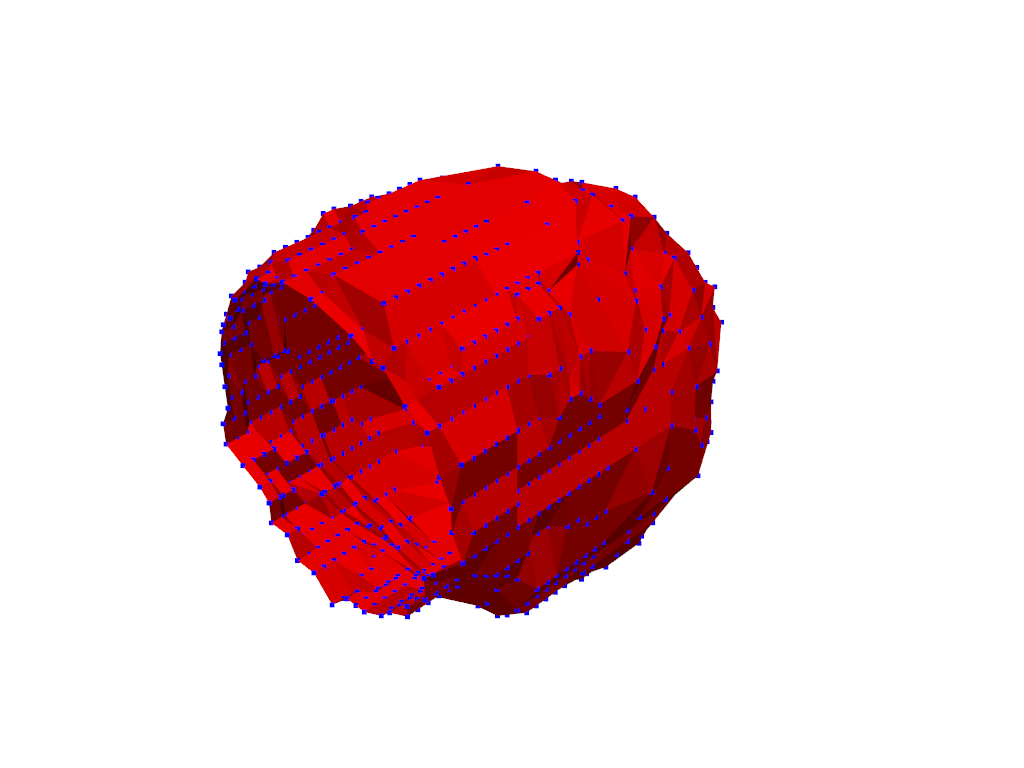

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


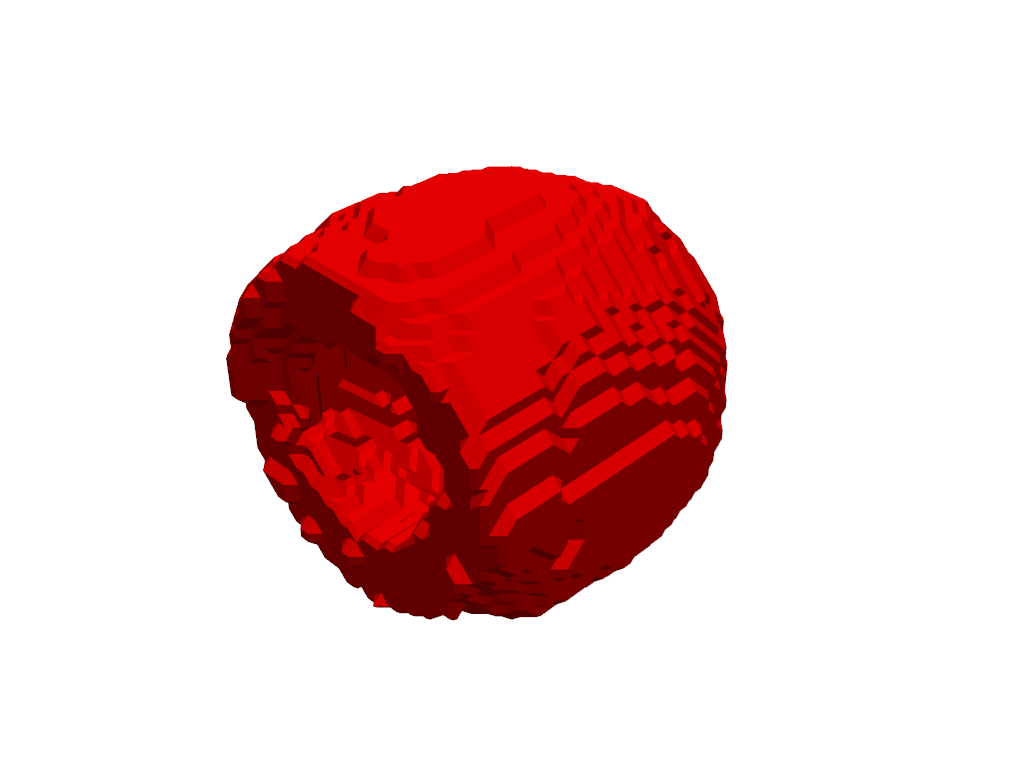

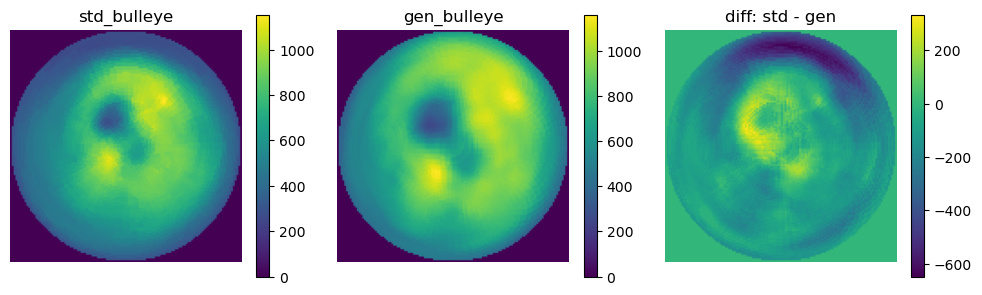

PSNR: 16.087501921768904, SSIM: 0.7157706558036412, NRMSE: 0.3164903413685623
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0004
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (51, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:26.850191810844645, distance:74.41663689688104
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:56749.79826306379, distance:23.08324259856411
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 31.734088888556766,
        "cx": 29.40799091191339
    },
    "radius": 13.934843307917786,
    "apex_z": 3,
    "base_z": 43,
    "dividing_z": 26.90226496187668
}


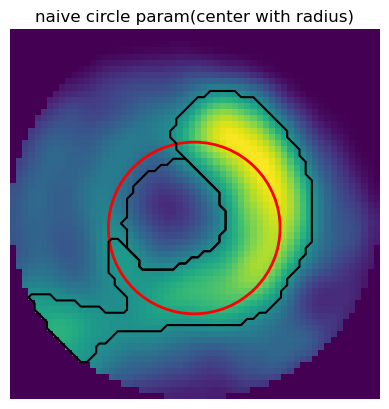

points_theoretical: (962, 3)
before: 680
after: 960
final: 961


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


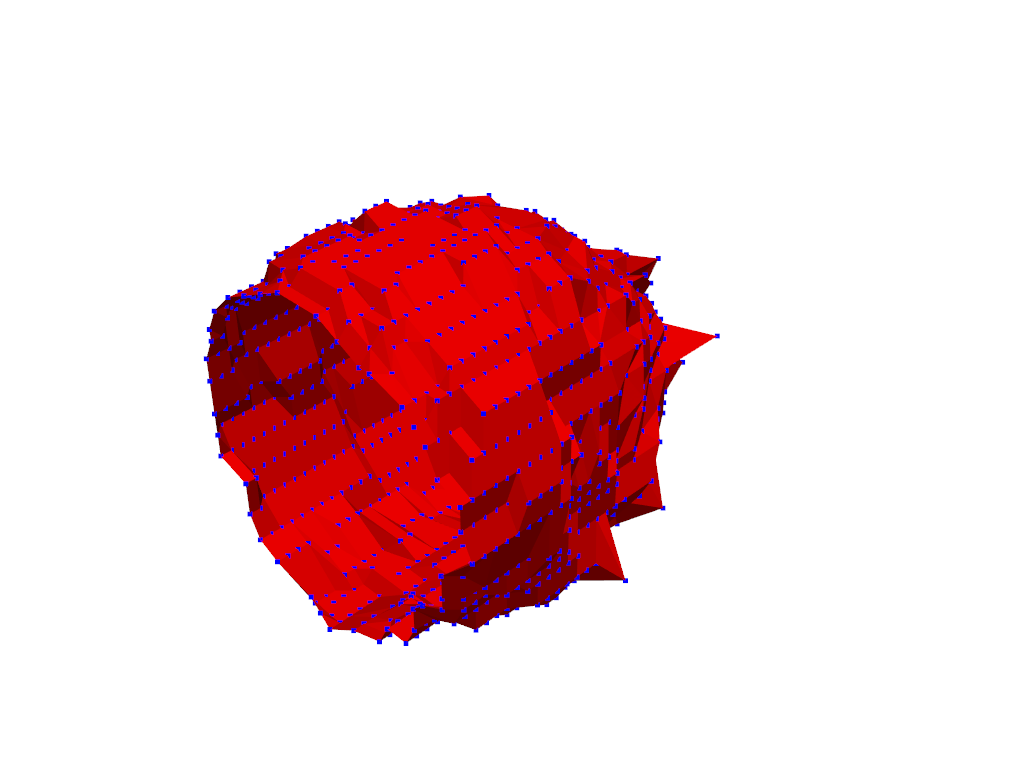

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


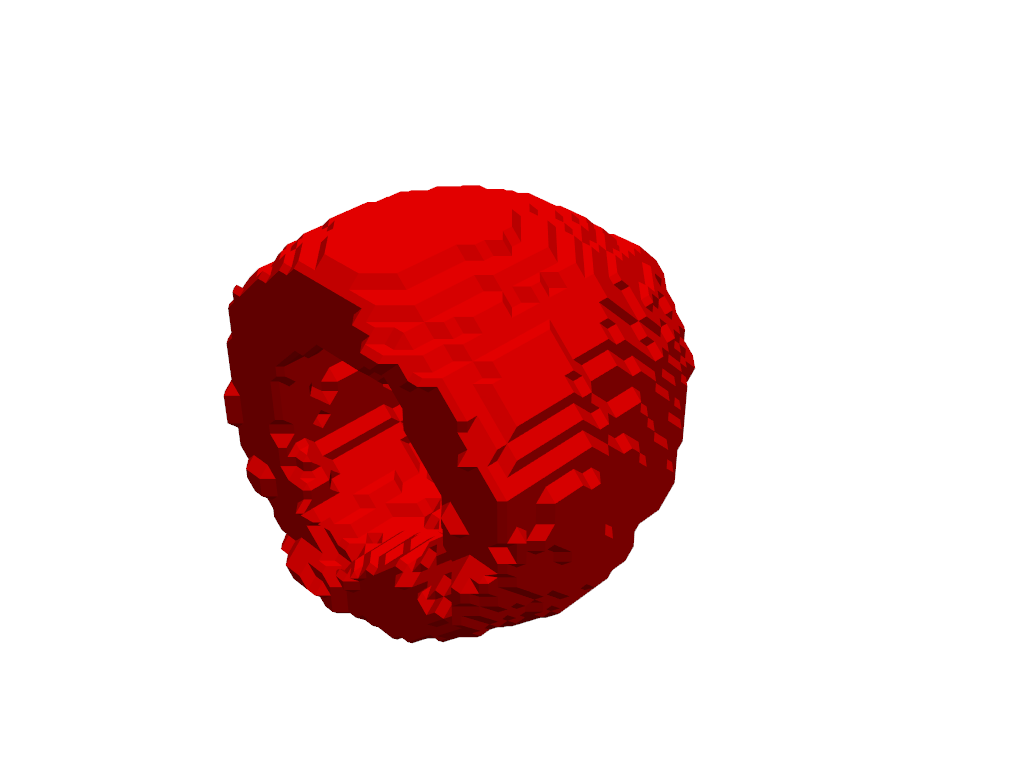

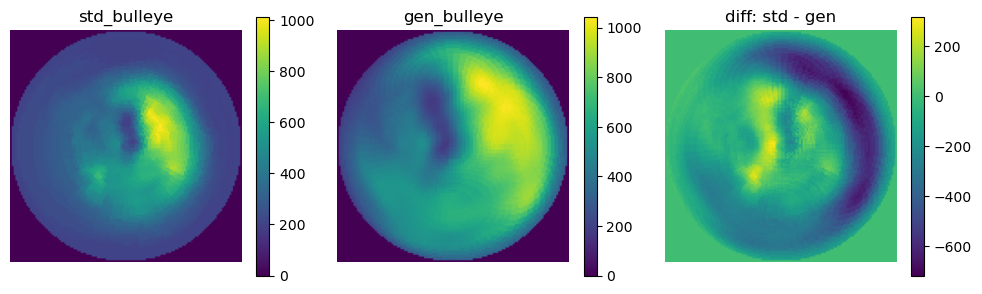

PSNR: 12.362210945642493, SSIM: 0.5035958762452206, NRMSE: 0.6928817832999128
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0005
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (63, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:96280.95209200164, distance:19.422390106091243
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 29.91822425524375,
        "cx": 30.732182164819964
    },
    "radius": 16.133831553741015,
    "apex_z": 2,
    "base_z": 50,
    "dividing_z": 29.20074733061152
}


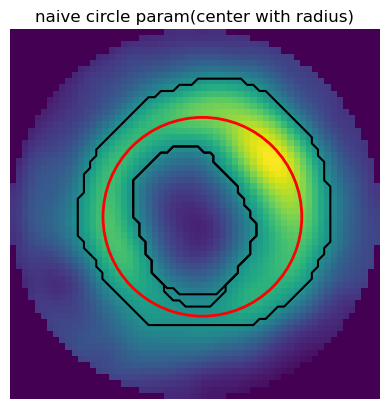

points_theoretical: (1122, 3)
before: 840
after: 1120
final: 1121


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


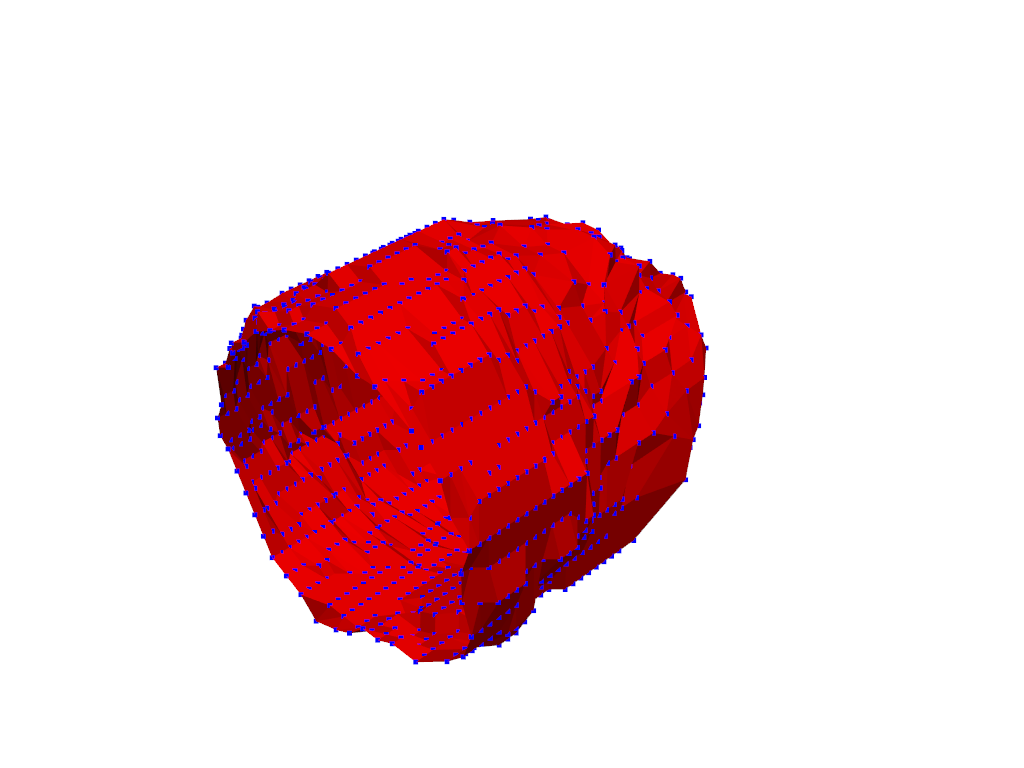

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


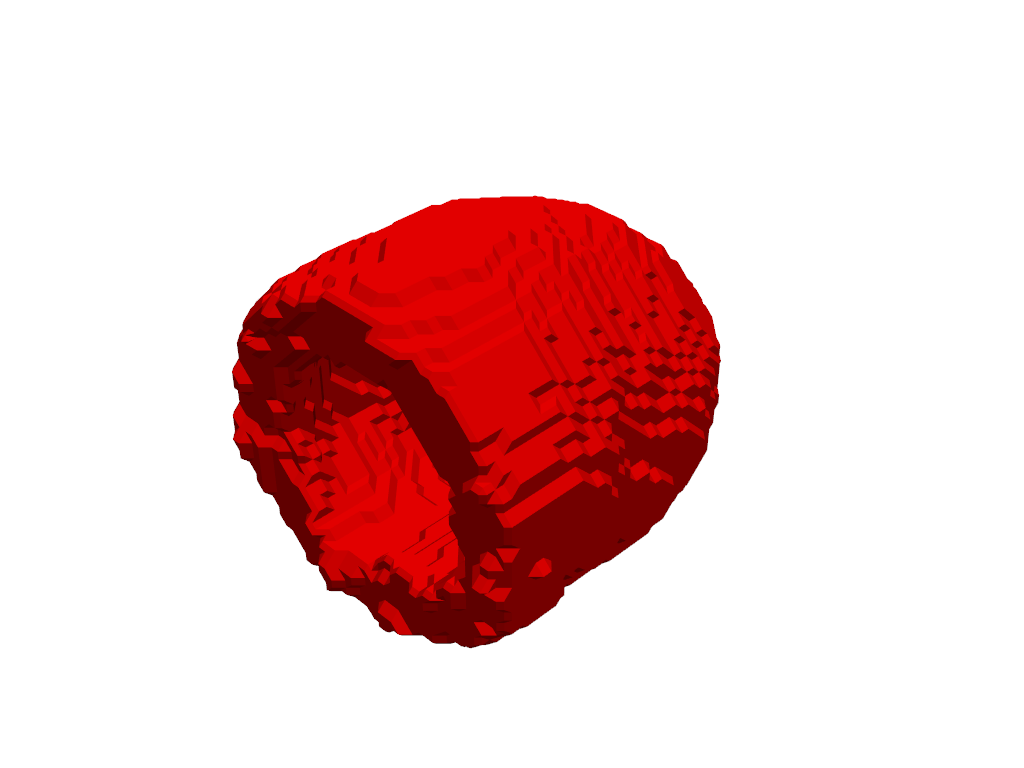

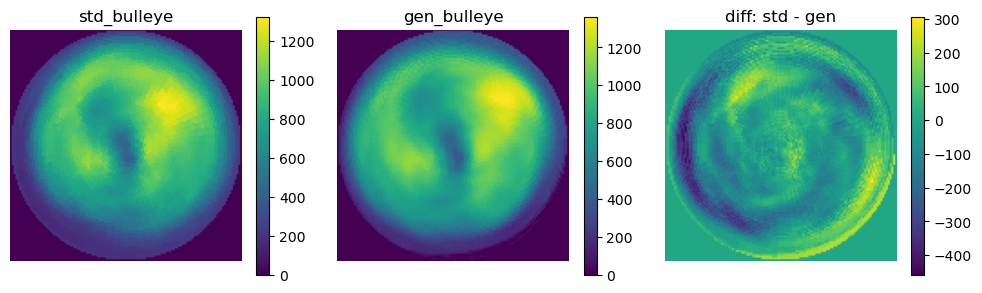

PSNR: 21.70044645647643, SSIM: 0.7515810583721496, NRMSE: 0.16628952331143537
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0006
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (75, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:91823.82025140143, distance:11.820454360713468
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:540.8395779041564, distance:122.99249248378908
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:69.04335037074337, distance:132.22220398718193
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:30.685933498108167, distance:114.38294905114752
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 34.9712909

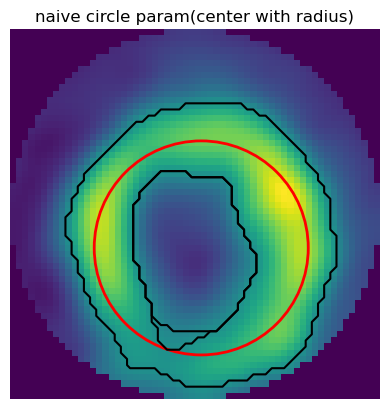

points_theoretical: (962, 3)
before: 680
after: 960
final: 961


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


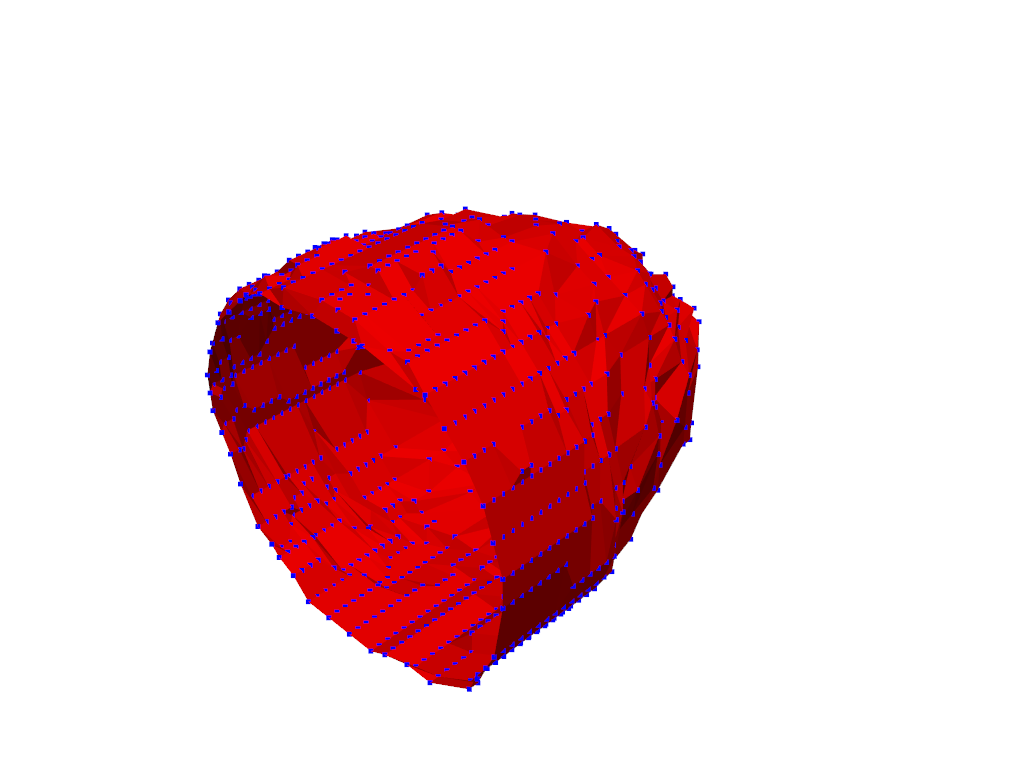

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


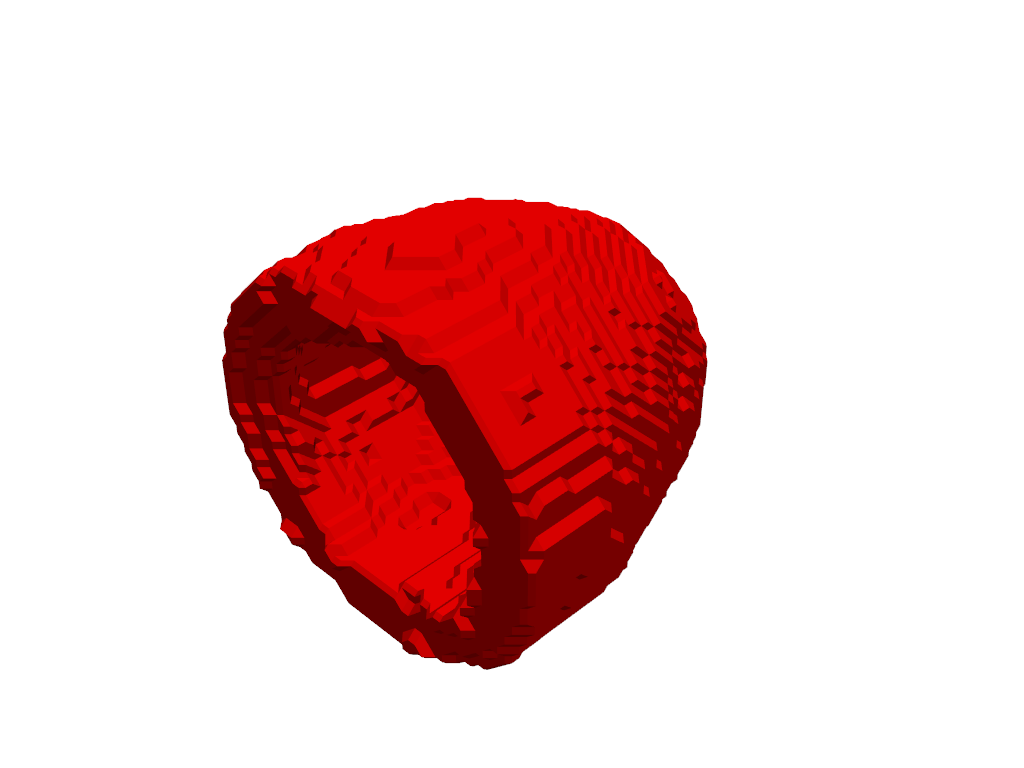

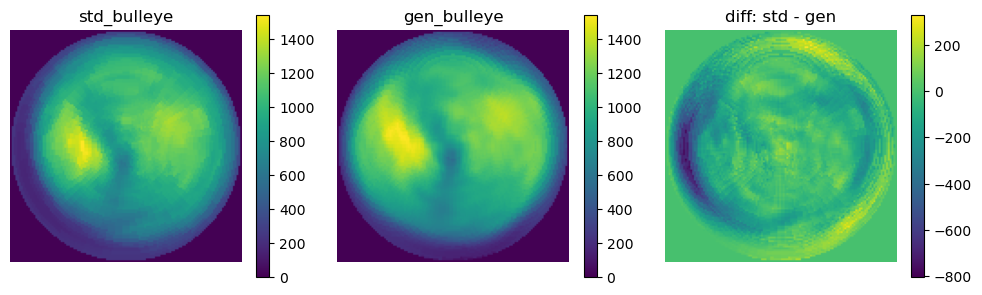

PSNR: 20.18035570813973, SSIM: 0.7560842001744056, NRMSE: 0.2006380314162287
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0007
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (69, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:65817.49161175475, distance:39.208537992323826
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 30.51958330121017,
        "cx": 33.39105212355888
    },
    "radius": 12.128805324027782,
    "apex_z": 2,
    "base_z": 42,
    "dividing_z": 23.193207986041674
}


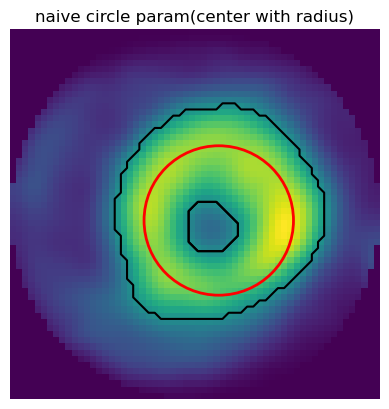

points_theoretical: (1042, 3)
before: 760
after: 1039
final: 1040


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


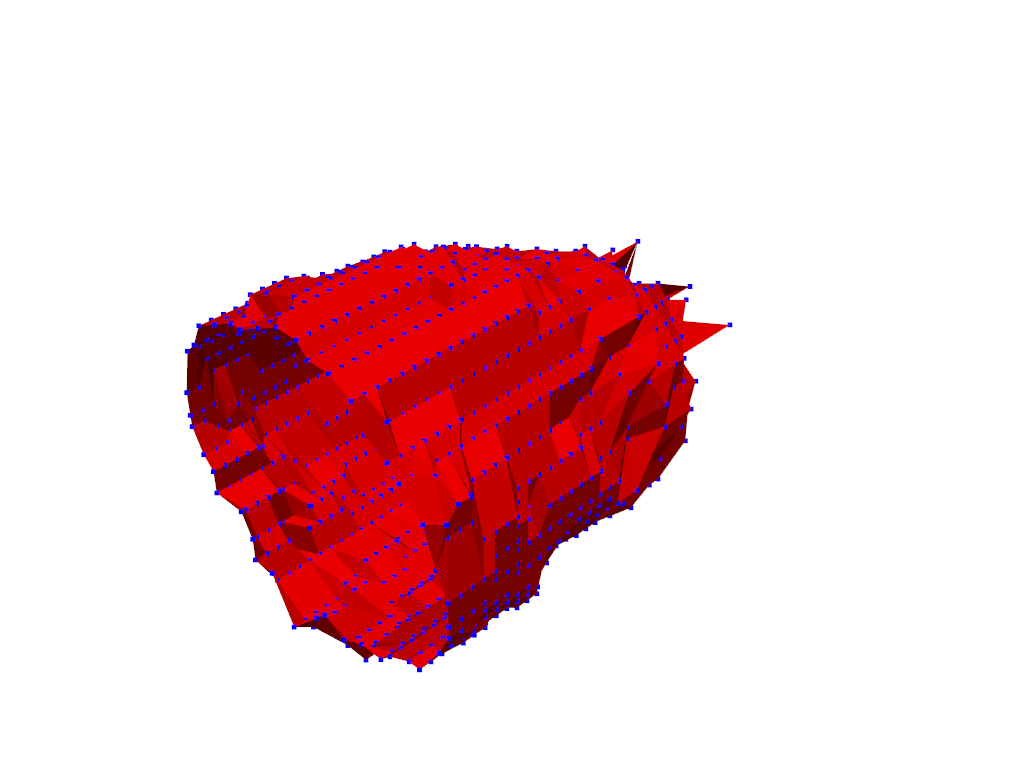

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


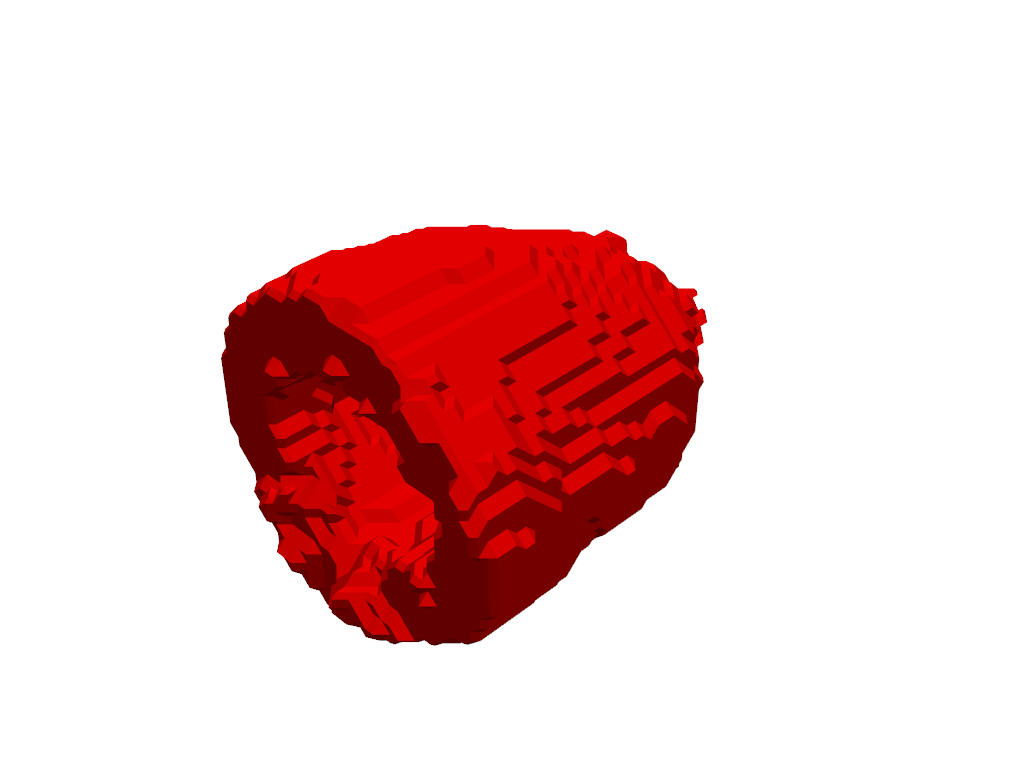

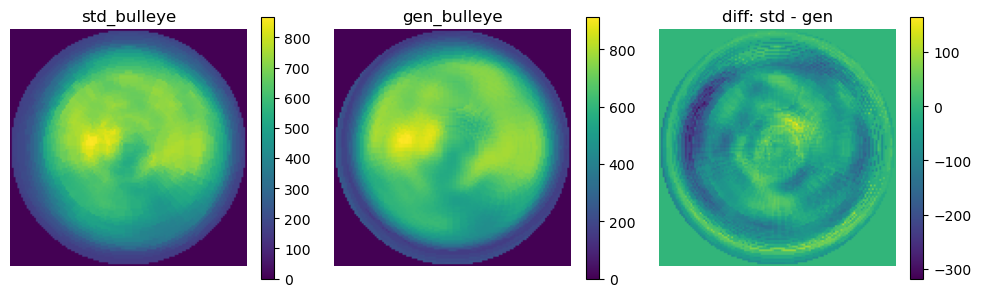

PSNR: 22.37102083245017, SSIM: 0.7814000014111759, NRMSE: 0.14403812569145316
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0008
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (57, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:99759.96980234965, distance:27.012567716764664
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:11.507225061790562, distance:105.4751471419932
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 30.53622192800737,
        "cx": 30.469021171652997
    },
    "radius": 14.303241258968235,
    "apex_z": 0,
    "base_z": 47,
    "dividing_z": 24.454861888452353
}


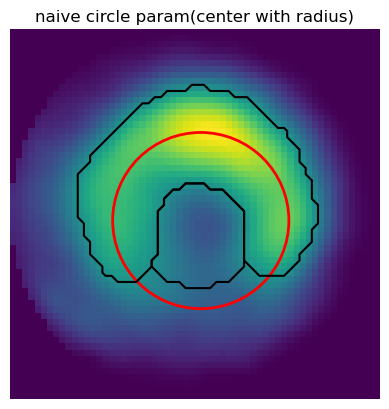

points_theoretical: (1202, 3)
before: 920
after: 1200
final: 1201


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


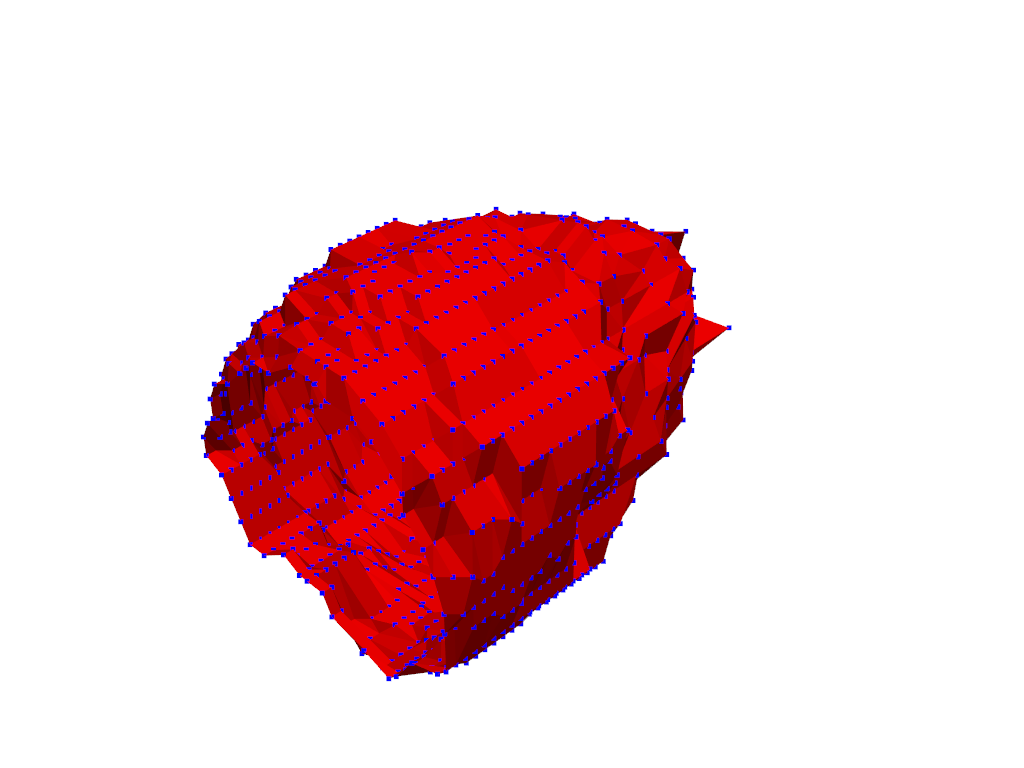

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


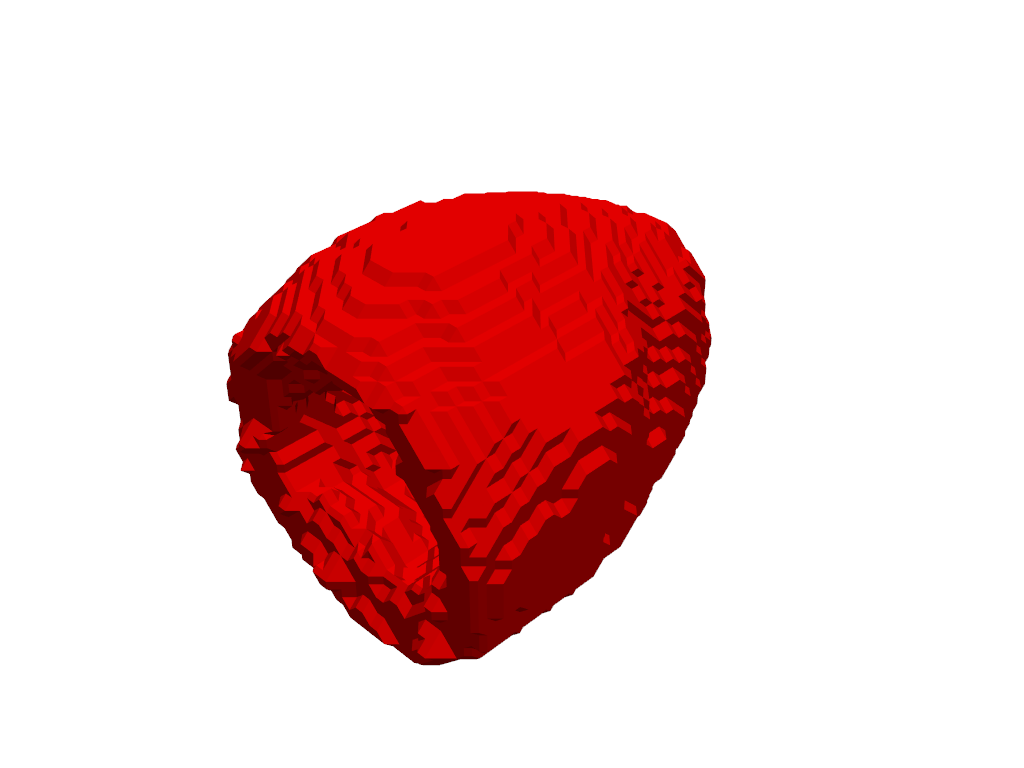

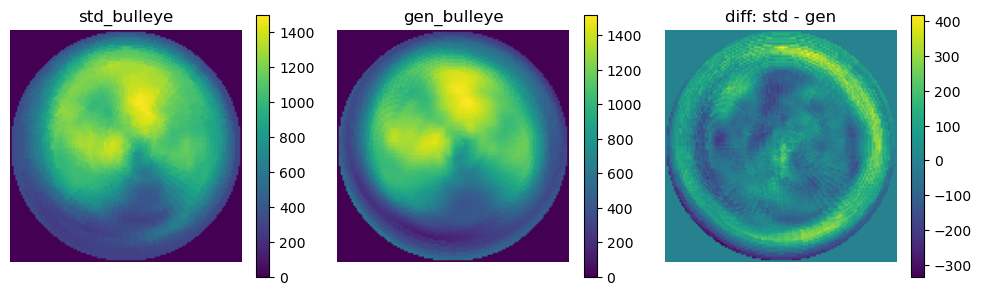

PSNR: 23.17705709891566, SSIM: 0.7483203386203442, NRMSE: 0.1362027469751604
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0009
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (63, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:96580.13994360818, distance:20.285749560171663
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:3.835741687263521, distance:113.08934851615862
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 29.13498152876304,
        "cx": 30.052540693320537
    },
    "radius": 15.625130888855391,
    "apex_z": 3,
    "base_z": 50,
    "dividing_z": 29.437696333283085
}


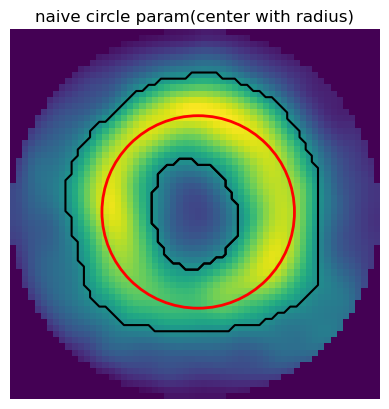

points_theoretical: (1122, 3)
before: 840
after: 1120
final: 1121


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


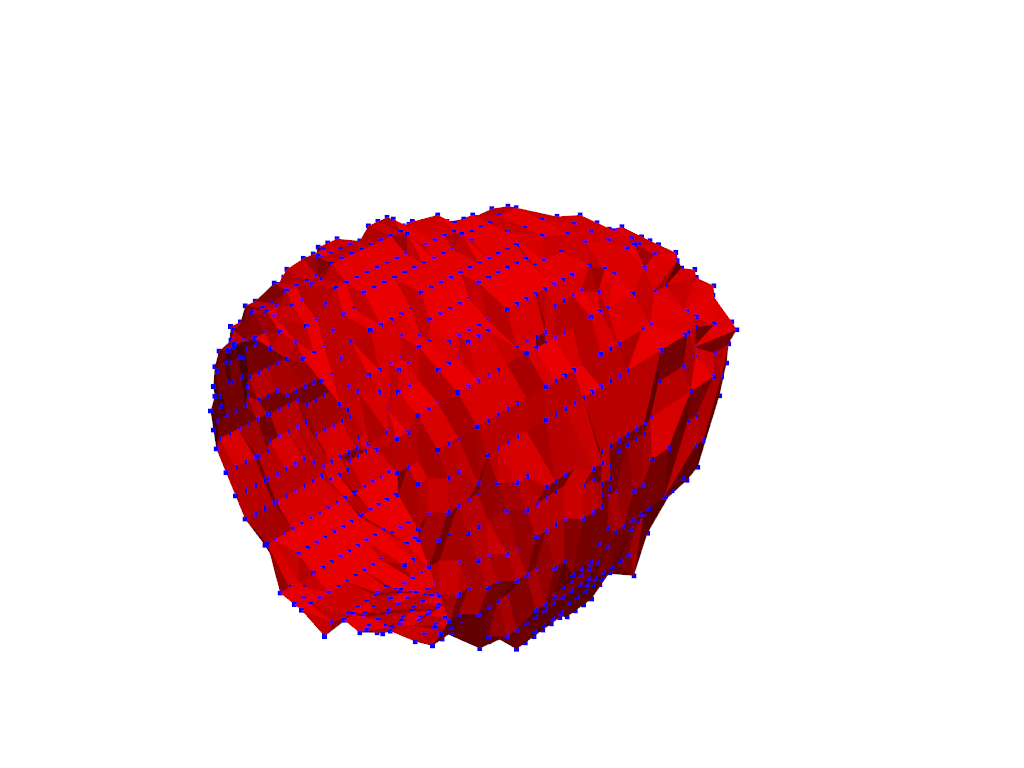

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


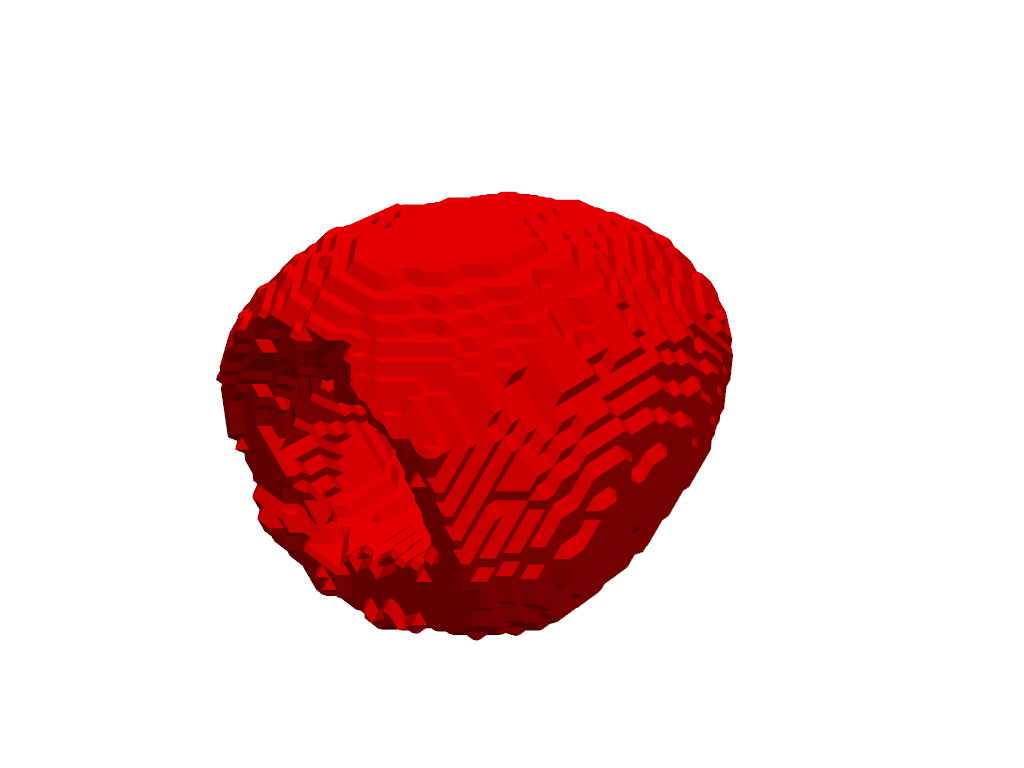

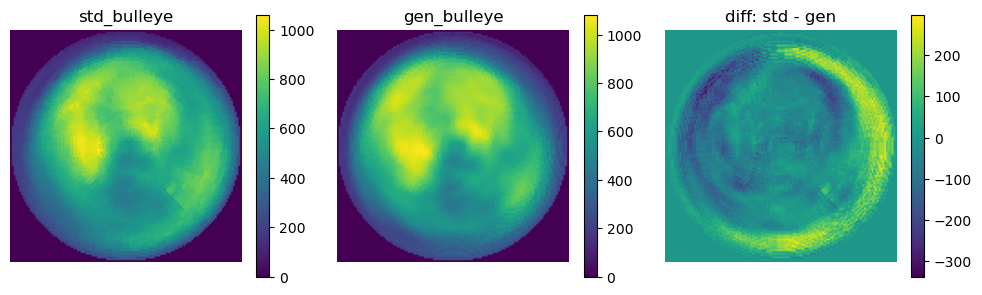

PSNR: 21.918005104849257, SSIM: 0.7875085886769319, NRMSE: 0.15448218649399606
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0010
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (63, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:50136.979594221484, distance:29.86069986095418
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 28.950770122592715,
        "cx": 30.133218287187958
    },
    "radius": 15.761397119497314,
    "apex_z": 3,
    "base_z": 39,
    "dividing_z": 29.64209567924597
}


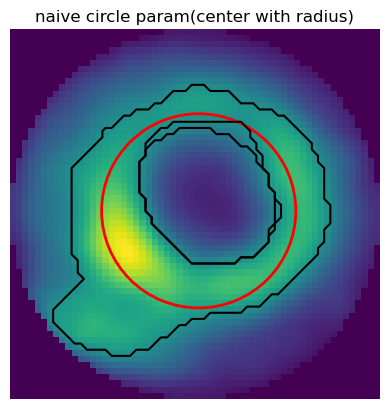

points_theoretical: (682, 3)
before: 400
after: 680
final: 681


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


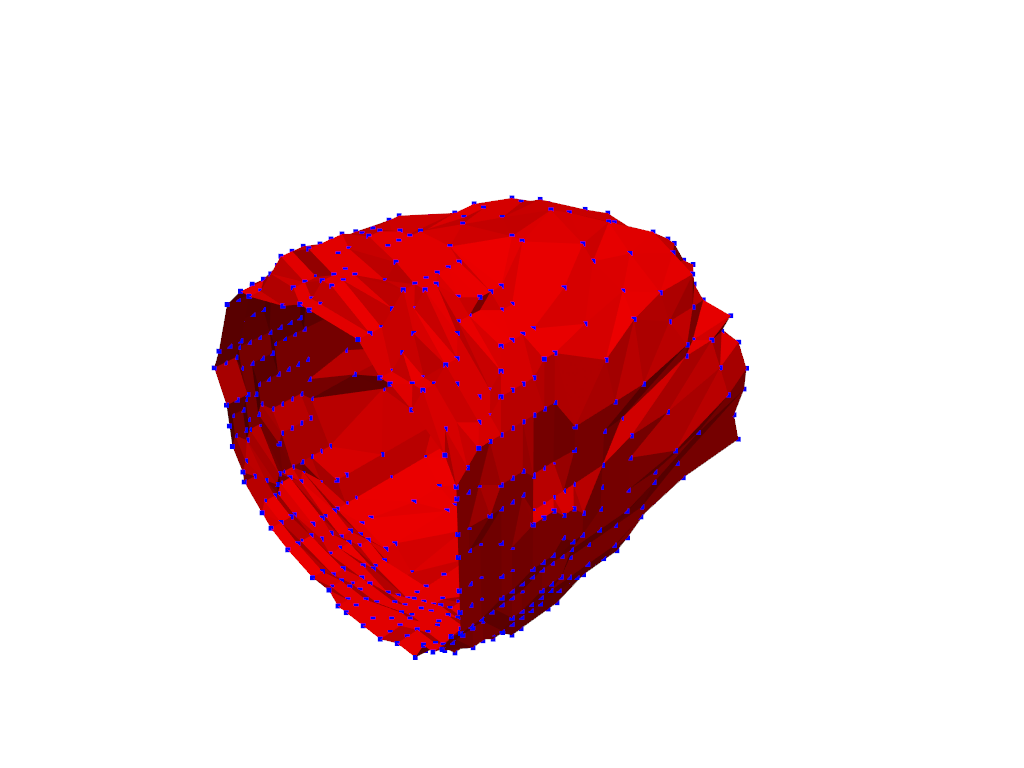

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


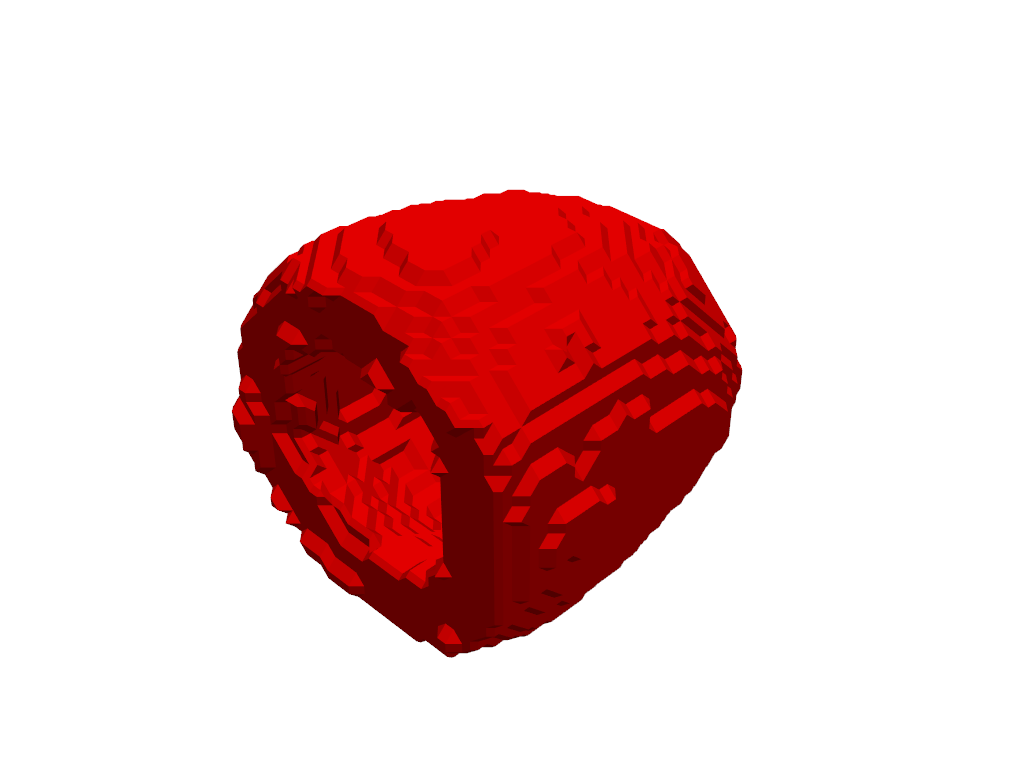

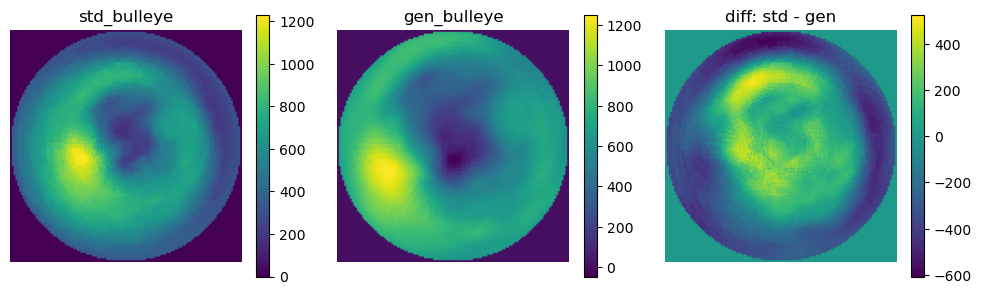

PSNR: 13.827083948313621, SSIM: 0.47341216642199535, NRMSE: 0.483333024170254
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0011
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (75, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:107838.04179572662, distance:18.340034742714032
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 33.41158076601403,
        "cx": 32.806109164239494
    },
    "radius": 15.952266348406901,
    "apex_z": 7,
    "base_z": 54,
    "dividing_z": 33.92839952261035
}


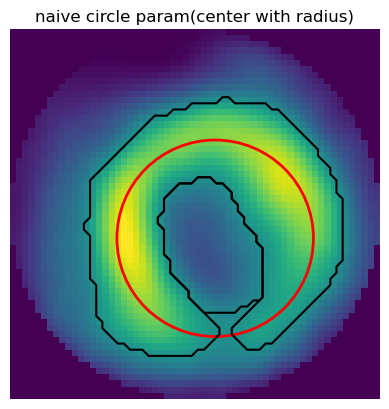

points_theoretical: (1122, 3)
before: 840
after: 1120
final: 1121


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


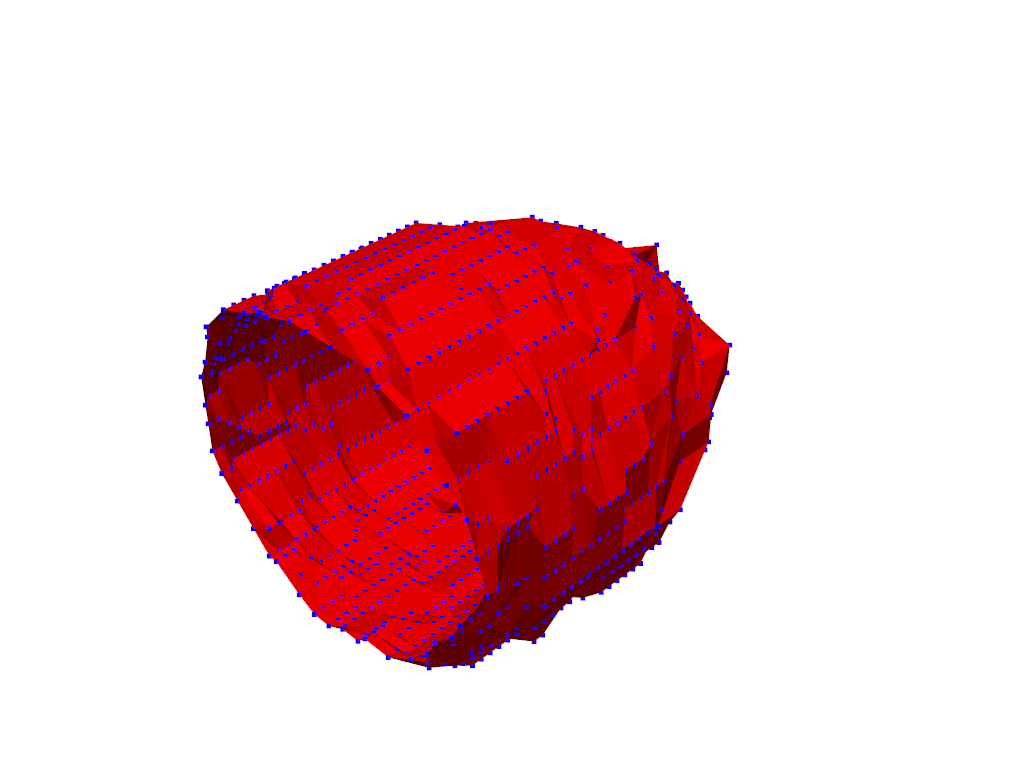

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


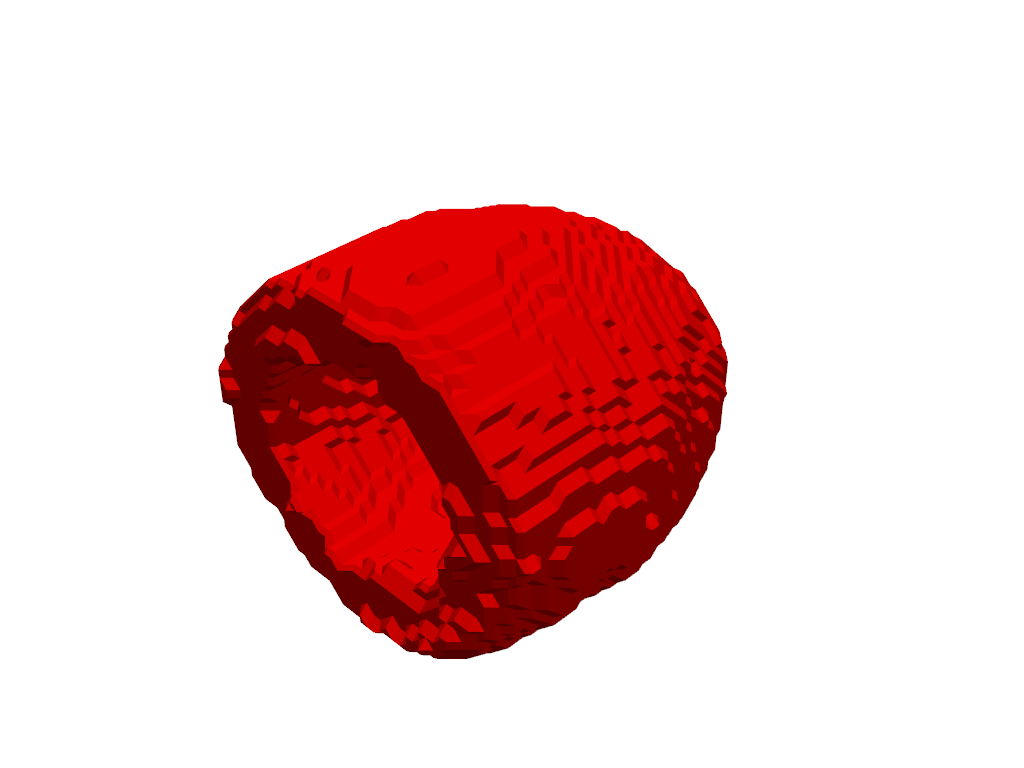

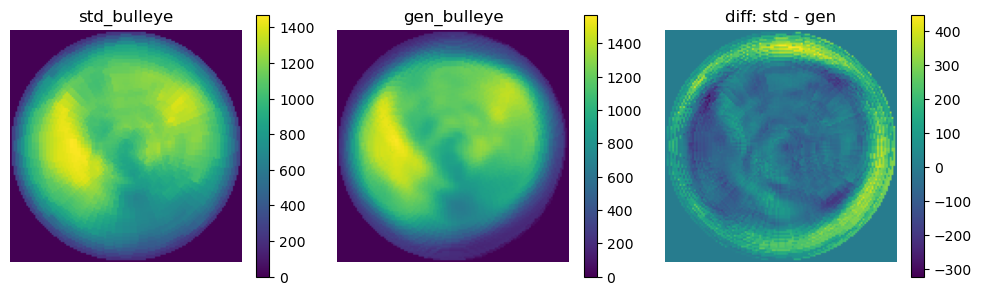

PSNR: 22.046001581928326, SSIM: 0.790796469129627, NRMSE: 0.13815912295319352
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0012
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (57, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:64398.26718746725, distance:9.041452554349293
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 32.41857179824556,
        "cx": 30.001423053960558
    },
    "radius": 9.642065902234835,
    "apex_z": 5,
    "base_z": 46,
    "dividing_z": 22.463098853352253
}


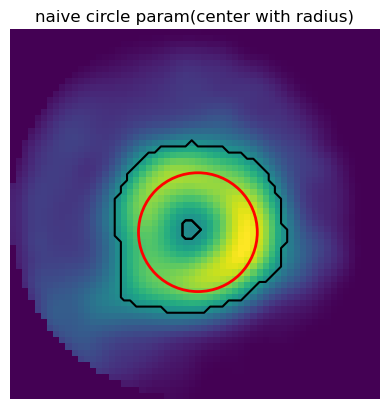

points_theoretical: (1242, 3)
before: 960
after: 1240
final: 1241


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


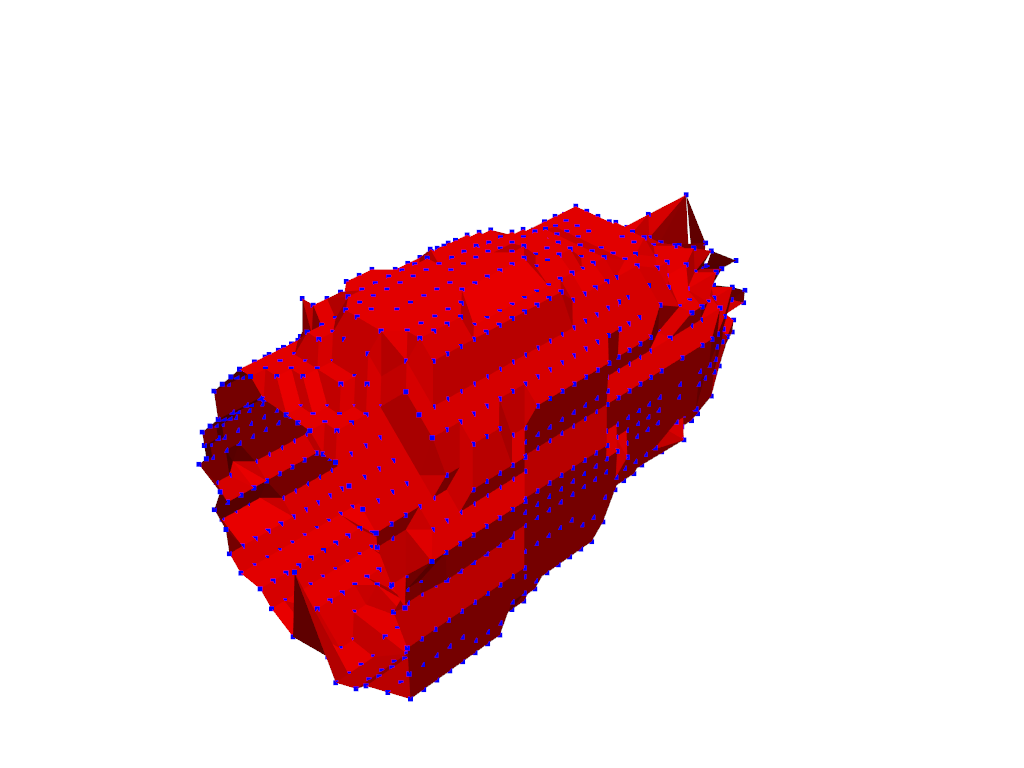

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


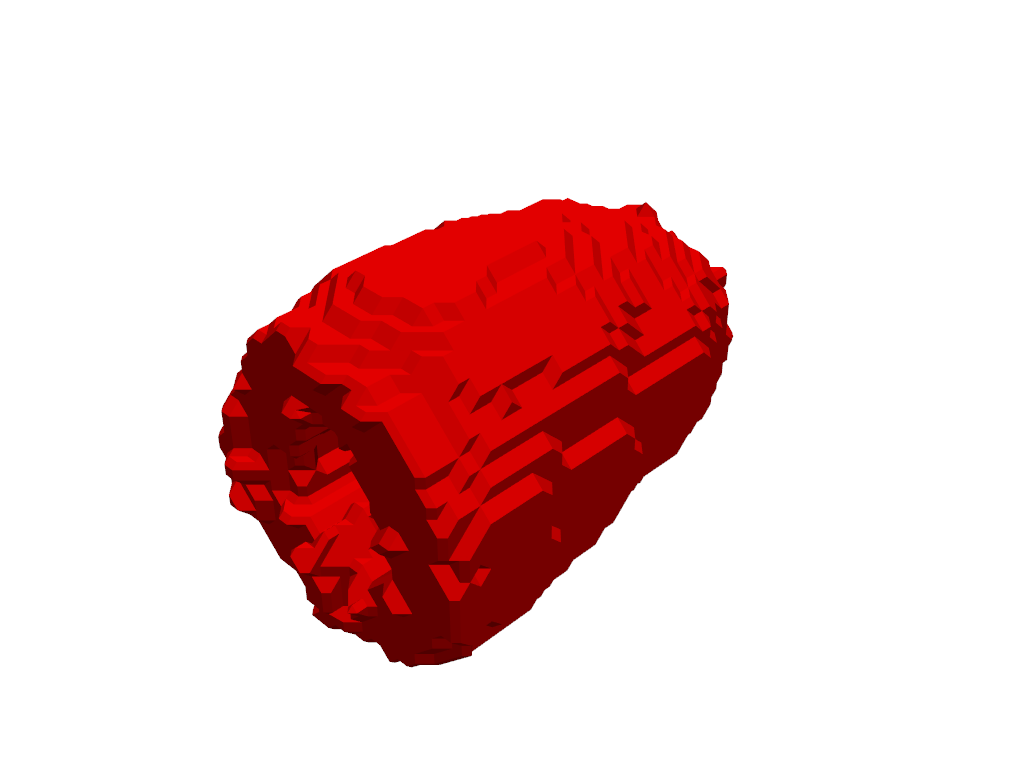

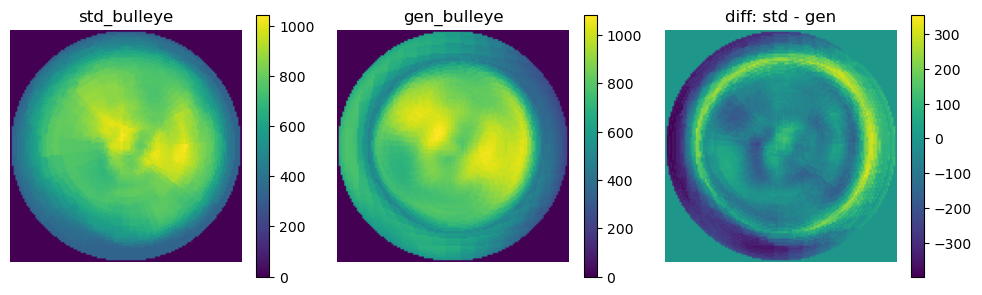

PSNR: 17.86431129923852, SSIM: 0.5545550375053822, NRMSE: 0.2215486994226445
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0013
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (75, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:46328.08809876881, distance:67.55538657499704
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 38.1676069358885,
        "cx": 27.003344119376862
    },
    "radius": 16.290224925937927,
    "apex_z": 16,
    "base_z": 60,
    "dividing_z": 43.43533738890689
}


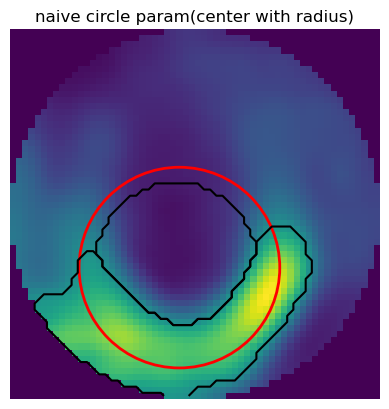

points_theoretical: (962, 3)
before: 680
after: 960
final: 961


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


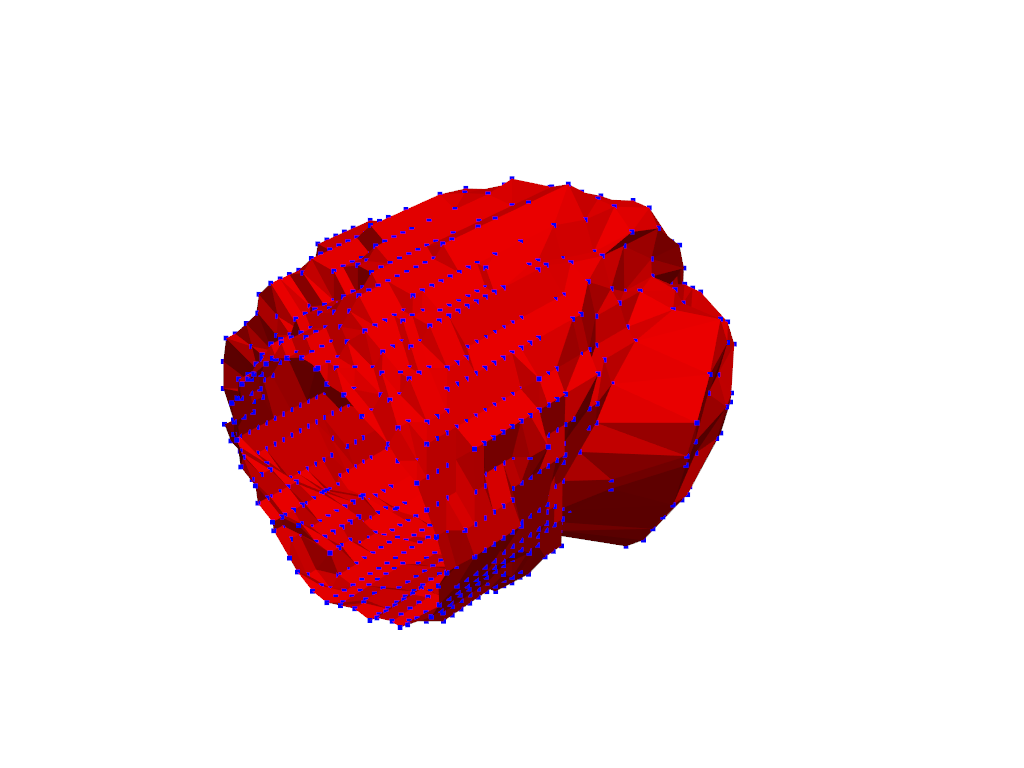

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


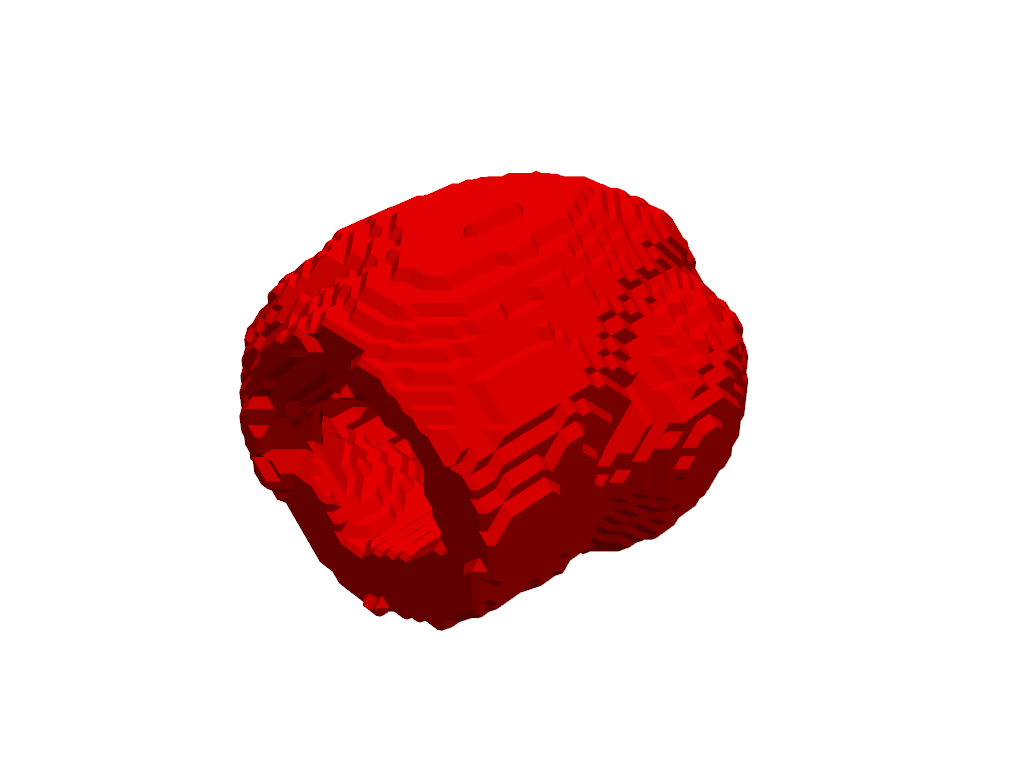

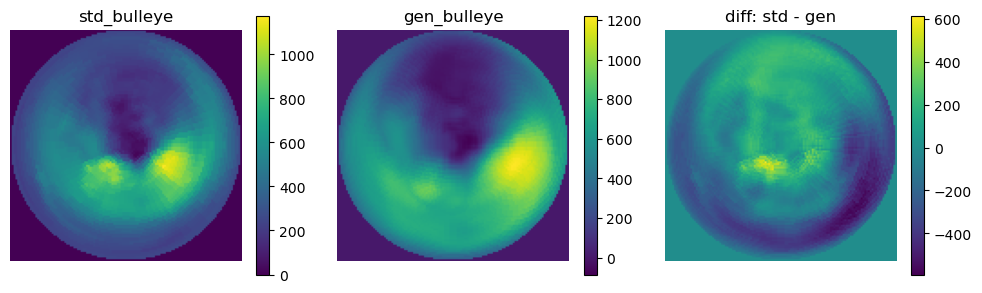

PSNR: 15.425461744278753, SSIM: 0.5354673333553127, NRMSE: 0.48322728161448025
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0014
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (63, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:93012.90017445311, distance:29.929015146360804
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:11.507225061790562, distance:113.99641024123937
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:11.507225061790562, distance:125.77782432463957
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:7.671483374527042, distance:125.88013620841797
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:7.67148337452704

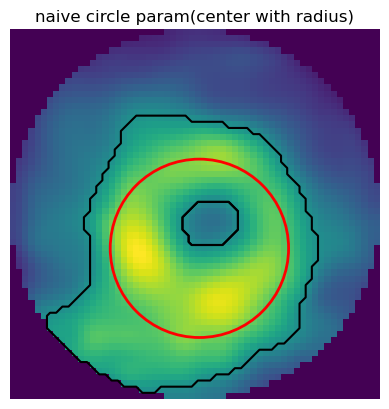

points_theoretical: (1082, 3)
before: 800
after: 1080
final: 1081


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


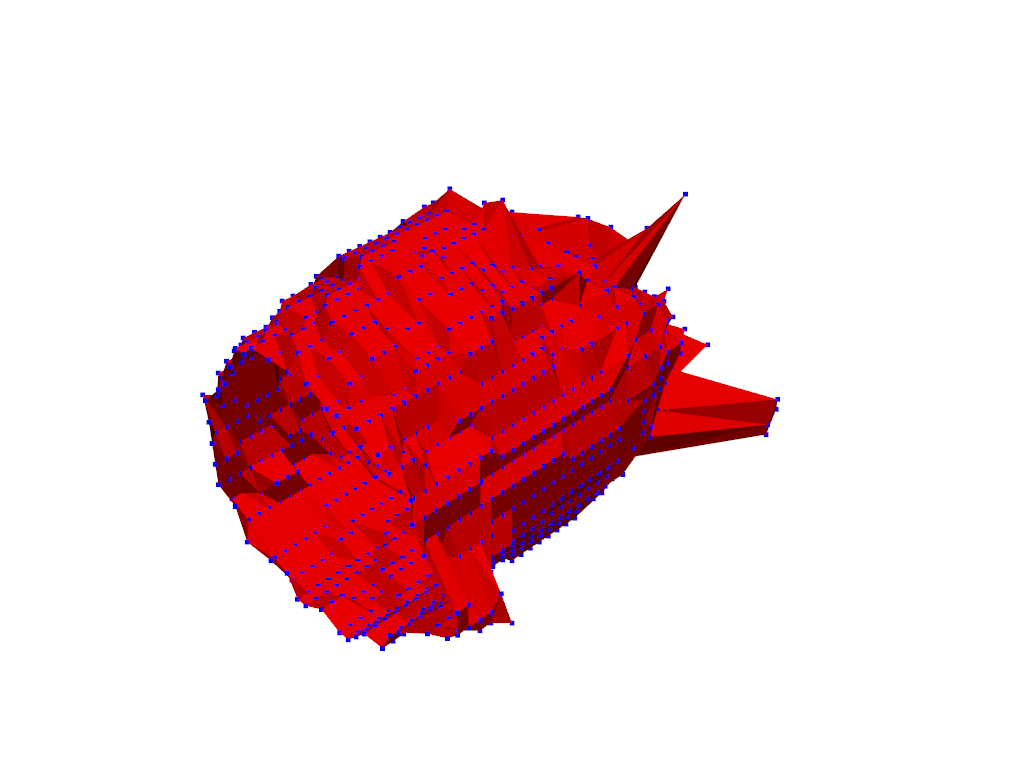

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


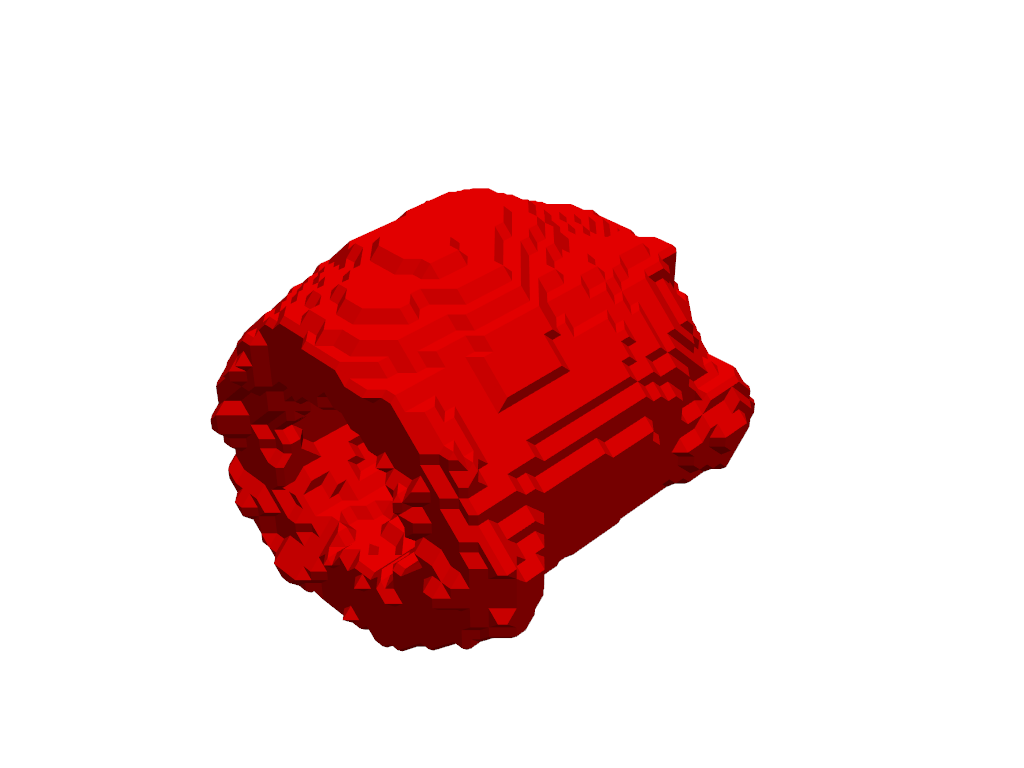

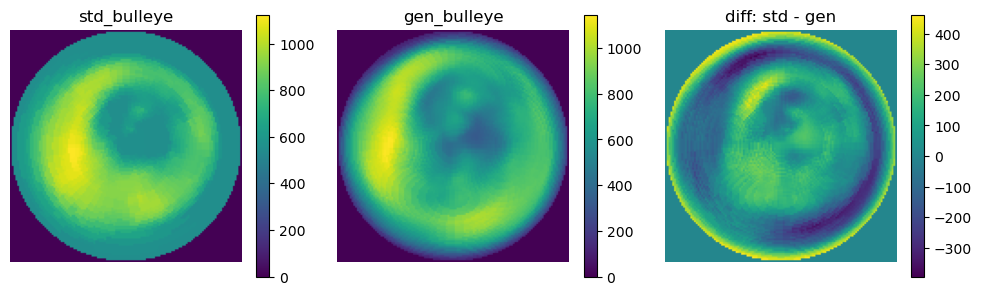

PSNR: 17.252385321024462, SSIM: 0.5237201910172127, NRMSE: 0.2364471897559369
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0015
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (75, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:69231.30171341929, distance:26.245800124422807
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:260.8304347339194, distance:83.44389436352864
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:38.357416872635206, distance:72.04356164558448
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:180.27985930138547, distance:84.37547369267355
naive_segment_lv_mask Success
naive_param: {
    "center": {
        "cy": 35.176588024

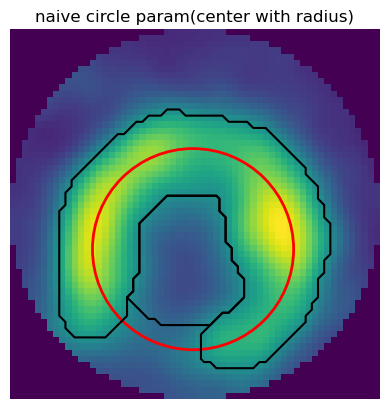

points_theoretical: (762, 3)
before: 480
after: 760
final: 761


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


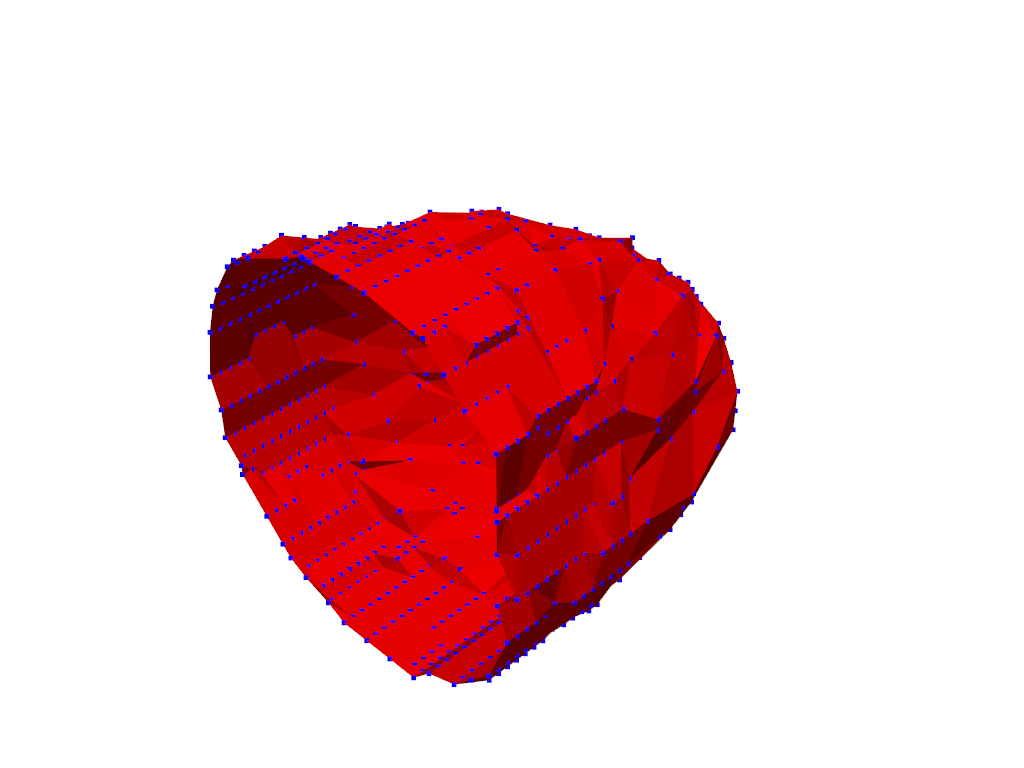

c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


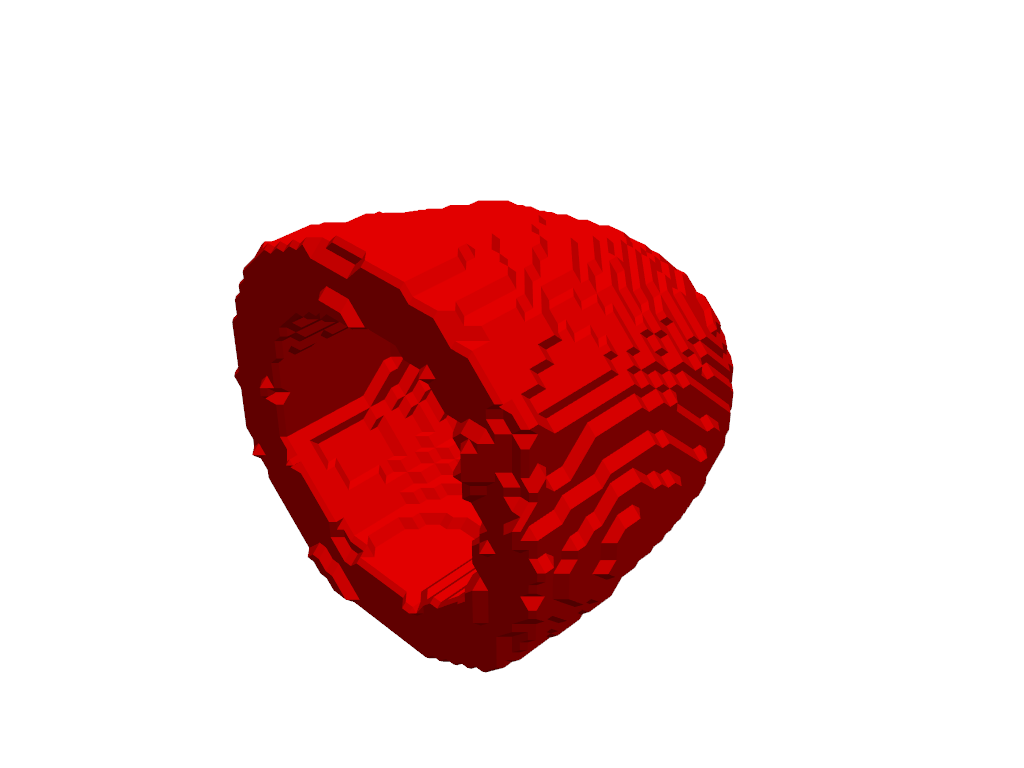

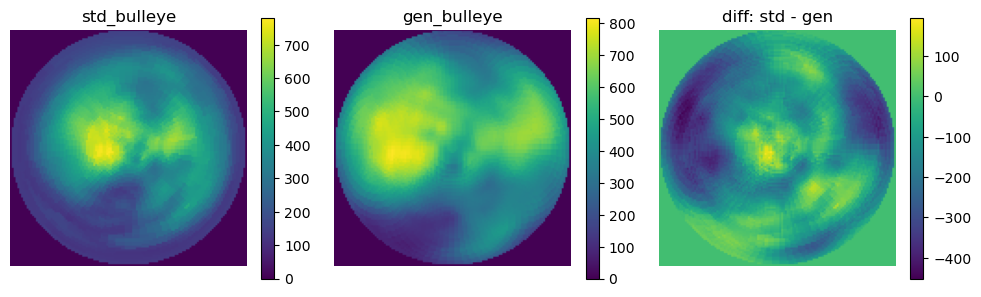

PSNR: 13.718057771286492, SSIM: 0.5670727450902973, NRMSE: 0.5151302007782415
patient_dir Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii\Patient_0016
std_polar_map: (128, 128)
std_polar_map: (128, 128)
************************************************************************************************
input img3d: (63, 60, 60), voxel_size: [2.21456671 2.21456639 2.21456639]
************************************************************************************************
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:94911.59230964856, distance:31.480332320675586
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:11.507225061790562, distance:120.02494137307386
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:3.835741687263521, distance:118.36541992489325
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:11.507225061790562, distance:118.25487872355498
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:

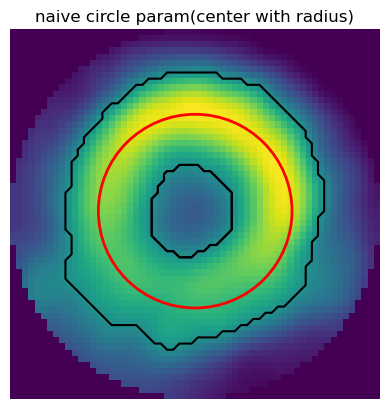

points_theoretical: (1162, 3)
before: 880
after: 1160
final: 1161


c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\core\utilities\points.py:52: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
c:\Users\ls031\.conda\envs\dev\Lib\site-packages\pyvista\jupyter\notebook.py:33: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


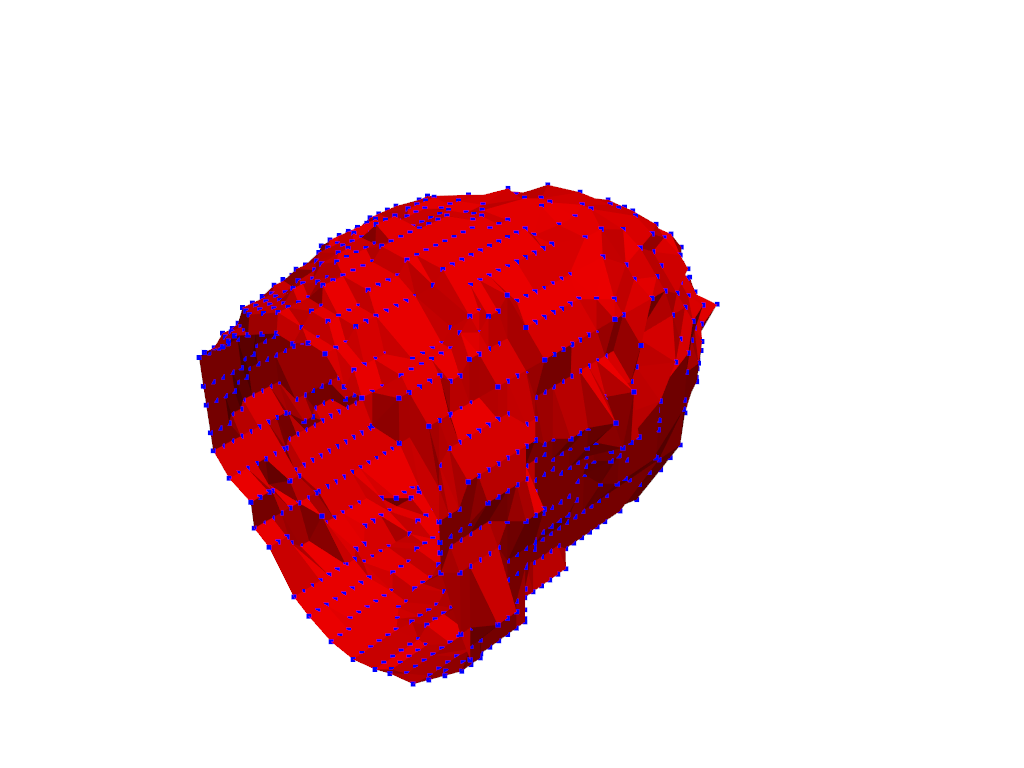

In [ ]:
base_dir = r"Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii"


total_data = {}
for patient_id in os.listdir(base_dir):
    if not patient_id.startswith("Patient_00"):
        continue
    patient_dir = os.path.join(base_dir, patient_id)
    
    print("patient_dir",patient_dir)
    gen_polar_map = np.zeros((128,128))
    std_polar_map = np.zeros((128,128))
    for file_name in os.listdir(patient_dir):
        if file_name.startswith("SA"):
            img_path = os.path.join(patient_dir, file_name)
            img3d, voxel_size = read_sitk_img(img_path)
            mask3d, param = lv_segment(img3d, voxel_size, verbose=2)
            # param["dividing_z"] = param["dividing_z"] + 10
            # param["apex_z"] = param["apex_z"] + param["radius"] + 3
            param["dividing_z"] = param["apex_z"] + param["radius"]*1.3 + 3
            # param["base_z"] = param["apex_z"] + max(param["base_z"] - param["apex_z"], 10)
            param["thickness"] = 5
            
            from scipy.ndimage import binary_dilation
            # 结构元素（可定义膨胀方式）
            structure = np.ones((3, 3, 3), dtype=np.uint8)  # 3x3x3 立方体结构
            
            mask3d = binary_dilation(mask3d, structure, iterations=5)
            
            gen_polar_map = gen_bulleye(img3d*mask3d, param)
        if file_name.startswith("Polar"):
            sitk_polar_map = sitk.ReadImage(os.path.join(patient_dir, file_name))
            std_polar_map = sitk.GetArrayFromImage(sitk_polar_map)[0] # 第一帧是静息, 后面是门控
            print(f"std_polar_map: {std_polar_map.shape}")

    show_bulleye(std_polar_map, gen_polar_map, save_dir=patient_dir)
    
    
    psnr_value, ssim_value, nrmse_value = cal_metric(std_polar_map, gen_polar_map)
    
    data = {
        "psnr": psnr_value,
        "ssim": ssim_value,
        "nrmse": nrmse_value
    }
    
    total_data[patient_id] = data
        
    # break

In [8]:
psnrs, ssims, nrmses = [], [], []

for key, info_dic in total_data.items():
    # print(info_dic)
    psnr_value = info_dic["psnr"]
    ssim_value = info_dic["ssim"]
    nrmse_value = info_dic["nrmse"]
    psnrs.append(psnr_value)
    ssims.append(ssim_value)
    nrmses.append(nrmse_value)

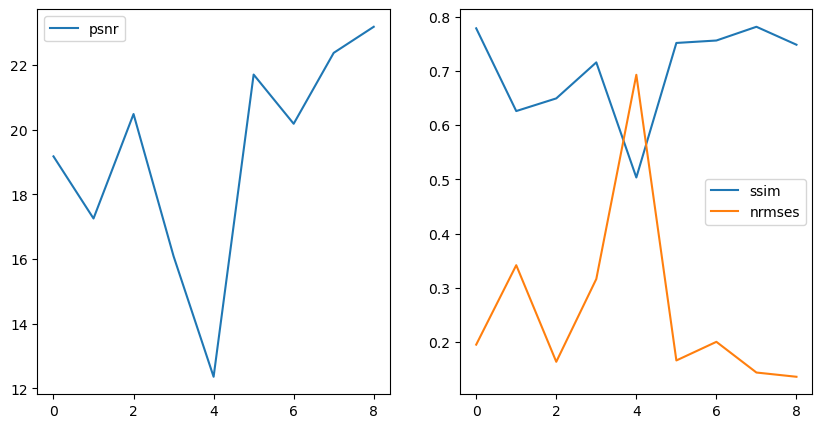

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(121)
plt.plot(psnrs, label="psnr")

plt.legend()


plt.subplot(122)
plt.plot(ssims, label="ssim")
plt.plot(nrmses, label="nrmses")
plt.legend()